# Group 3 Project Code

## Ralph Bernardo, John Frasier, David Herrera, and Emmanuel Mendez


In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 03/18/26 21:19:25


## Import Python libraries and dataset from Kaggle

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [3]:
# [AI-START] The following block was repurposed from Kaggle with Google Gemini 3.1 Pro's input

print("Fetching and loading the asteroid dataset directly into memory...")

# Download, unzip, and load the dataset

asteroids_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sakhawat18/asteroid-dataset", # The Kaggle location for the dataset
  "dataset.csv", # The specific file from Kaggle
  pandas_kwargs={"low_memory": False} # Prevents the mixed data type warning described below
)

print("Success! Asteroid dataset is available.")

# [AI-END]

Fetching and loading the asteroid dataset directly into memory...


100%|██████████| 435M/435M [00:28<00:00, 16.2MB/s]


Success! Asteroid dataset is available.


In [4]:
# Check quality of data pulled from Kaggle

asteroids_df.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [5]:
# This warning was received when loading the dataset locally without the low_memory=False option

# /tmp/ipython-input-2139934755.py:3:DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.

In [6]:
# Examine Columns (3,4,5) that produced the mixed data type warning

asteroids_df.iloc[:, 3:6]

,pdes,name,prefix
0,1,Ceres,NaN
1,2,Pallas,NaN
2,3,Juno,NaN
3,4,Vesta,NaN
4,5,Astraea,NaN
...,...,...,...
958519,6013 P-L,NaN,NaN
958520,6331 P-L,NaN,NaN
958521,6344 P-L,NaN,NaN
958522,2060 T-2,NaN,NaN


## Explore data

In [7]:
# Display shape of dataset

asteroids_df.shape

(958524, 45)

In [8]:
# Display columns

asteroids_df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

In [9]:
# Display info about dataset

asteroids_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [10]:
# Check for duplicates

asteroids_df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
958519,False
958520,False
958521,False
958522,False


In [11]:
# Check distribution of target variable

asteroids_df['pha'].value_counts()

,count
pha,
N,936537
Y,2066


In [12]:
# View distribution of target variable as proportions

asteroids_df['pha'].value_counts(normalize=True)

,proportion
pha,
N,0.997799
Y,0.002201


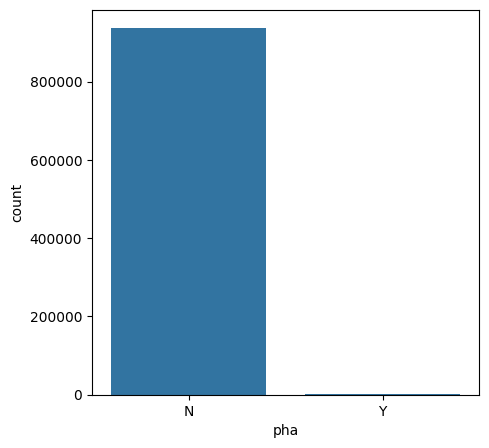

In [13]:
# Display bar chart of distribution of target variable

plt.figure(figsize=[5,5])
sns.countplot(x='pha', data=asteroids_df)
plt.show()

In [14]:
# name and prefix are mostly null -> will drop

In [15]:
# Set full_name as the index

asteroids_df_clean = asteroids_df.set_index('full_name') # Create new variable for data manipulation

In [16]:
# Explore object dtype because of non-numeric values

# pha is our target variable

# id, pdes, name, prefix, neo, orbit_id, equinox, class are objects -> see what they look like

asteroids_df_clean.select_dtypes(exclude='number')

,id,pdes,name,prefix,neo,pha,orbit_id,equinox,class
full_name,,,,,,,,,
1 Ceres,a0000001,1,Ceres,NaN,N,N,JPL 47,J2000,MBA
2 Pallas,a0000002,2,Pallas,NaN,N,N,JPL 37,J2000,MBA
3 Juno,a0000003,3,Juno,NaN,N,N,JPL 112,J2000,MBA
4 Vesta,a0000004,4,Vesta,NaN,N,N,JPL 35,J2000,MBA
5 Astraea,a0000005,5,Astraea,NaN,N,N,JPL 114,J2000,MBA
...,...,...,...,...,...,...,...,...,...
(6013 P-L),bPLS6013,6013 P-L,NaN,NaN,N,N,JPL 5,J2000,MBA
(6331 P-L),bPLS6331,6331 P-L,NaN,NaN,N,N,8,J2000,MBA
(6344 P-L),bPLS6344,6344 P-L,NaN,NaN,Y,Y,17,J2000,APO


In [17]:
# name and prefix are mostly null and non-numeric

# id, pdes, neo, orbit_id, equinox, class are non-numeric

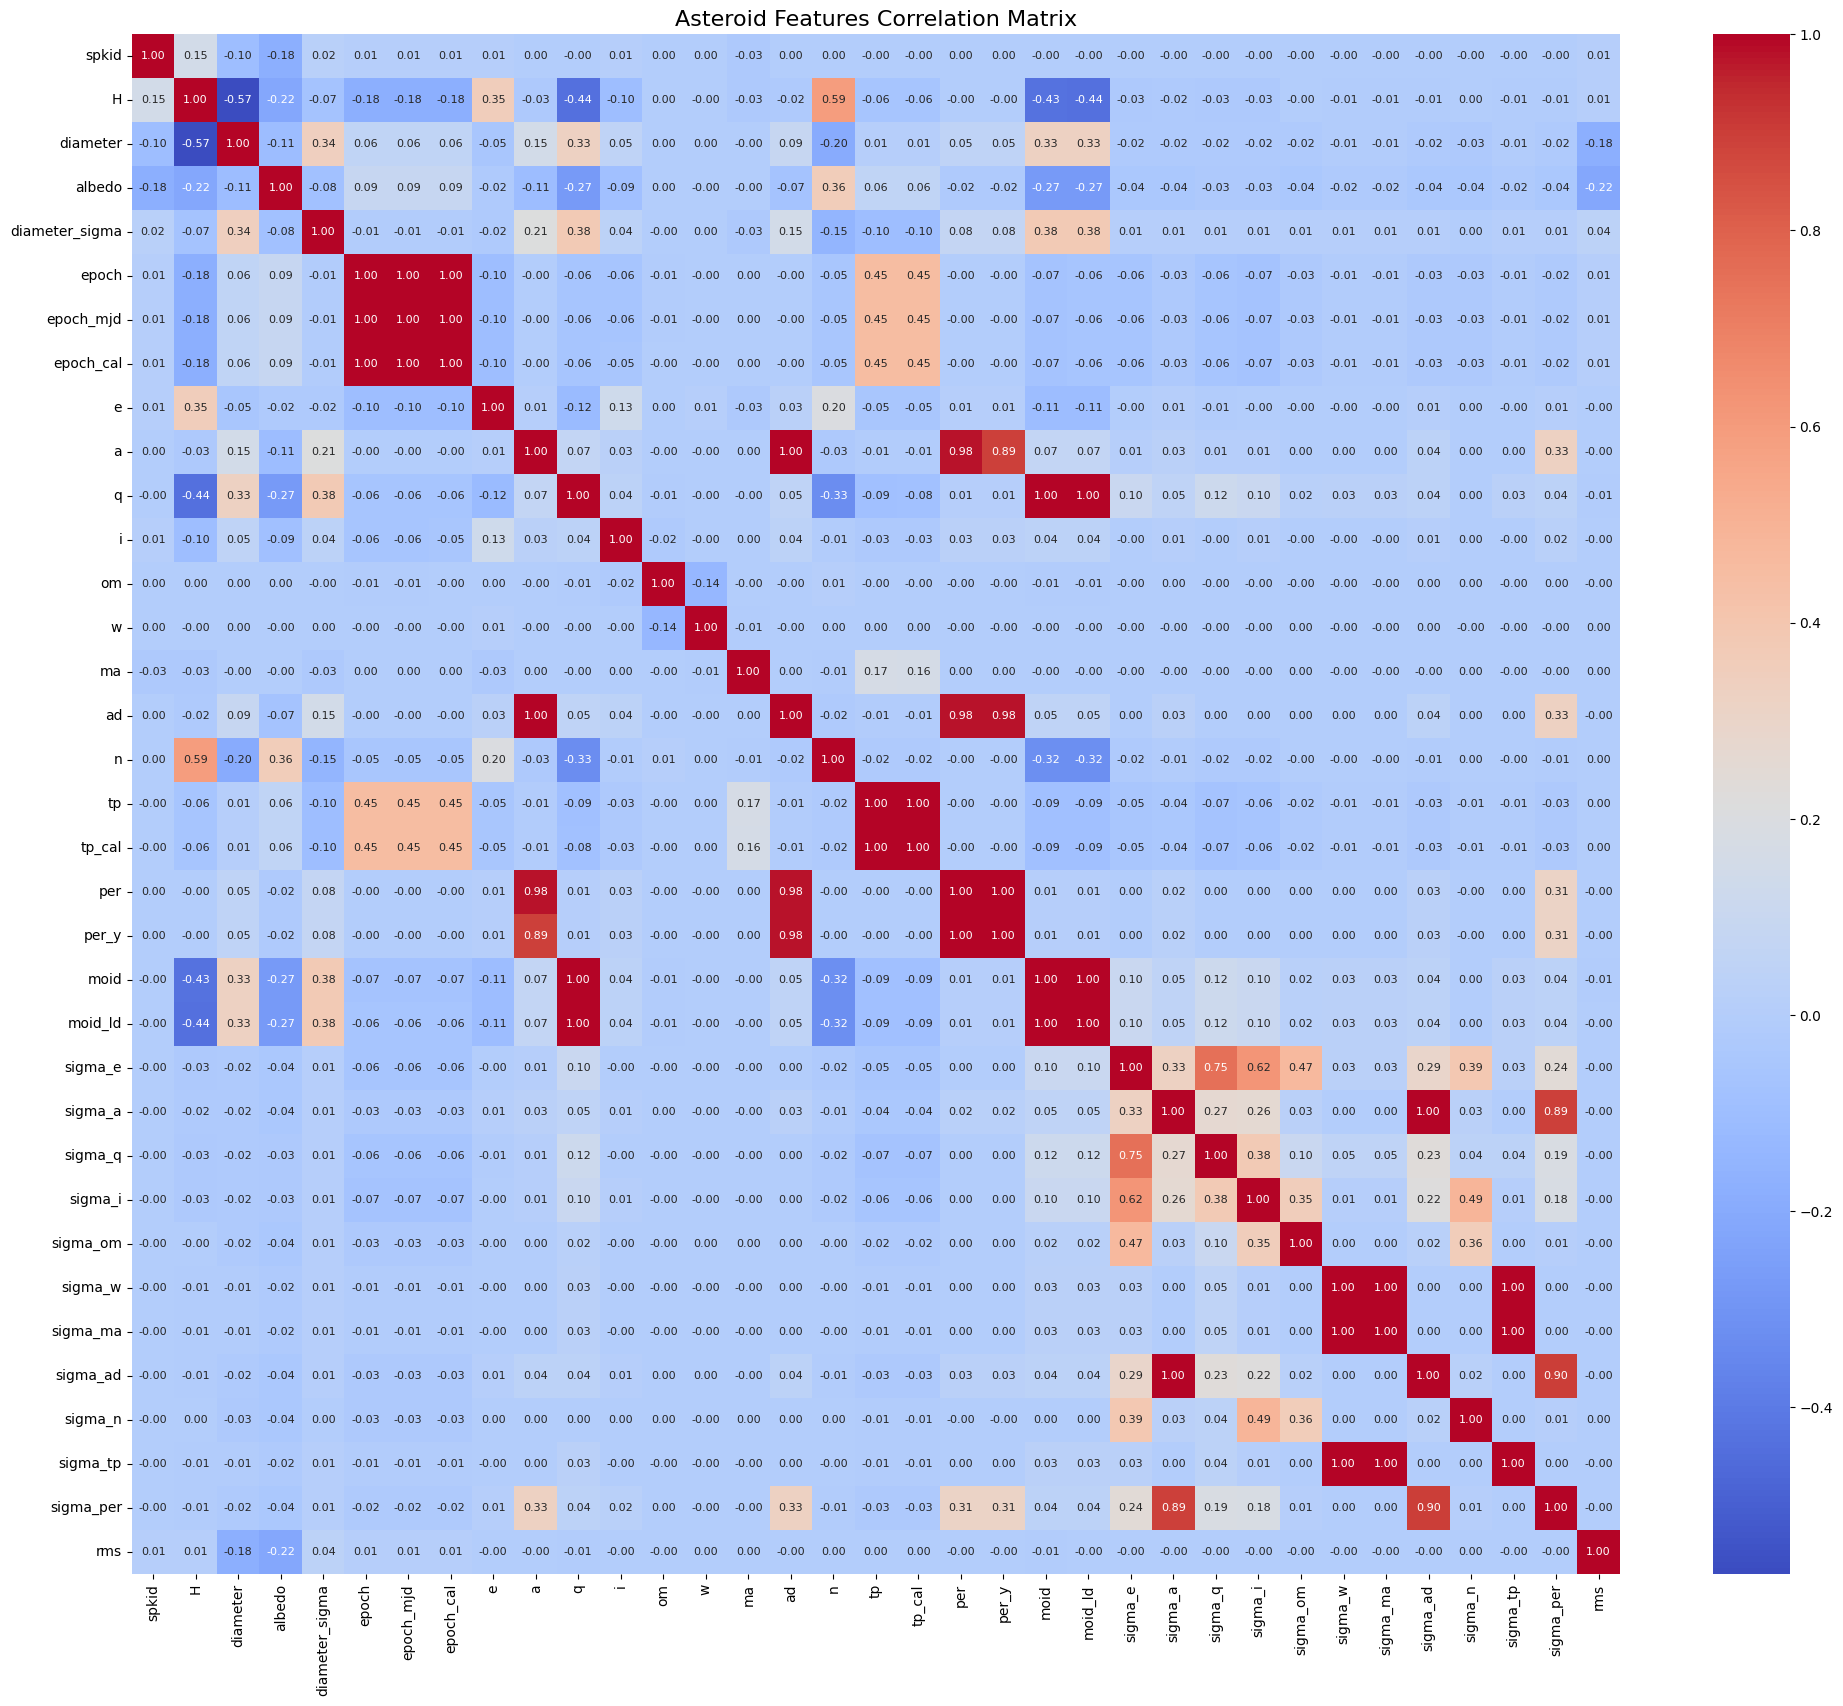

In [18]:
# Create Correlation Matrix to check for collinearity and multicollinearity

plt.figure(figsize=(24, 20))

correlation_matrix = asteroids_df_clean.corr(numeric_only=True).round(2) # Remove non-numeric from correlation matrix

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})

plt.title('Asteroid Features Correlation Matrix', fontsize=16)
plt.show()

## Clean data

In [19]:
# Consider collinearity and multicollinearity (using Kaggle descriptions) and columns to drop

# moid: earth minimum orbit intersection distance in AU -> keep for hypothesis
# moid_ld: earth minimum orbit intersection distance in lunar distance -> redundant

# per: period in days
# per_y: period in years -> redundant

# epoch: Julian Day format
# epoch_mjd: Modified Julian Day format -> redundant
# epoch_cal: Calendar Day format -> redundant

# tp: Julian Day format
# tp_cal: Calendar Day format -> redundant

# epoch and tp are timestamps instead of orbital info and can be dropped as well

In [20]:
# Other numeric columns to remove:

# These are uncertainty (error estimates) for features in the data, labeled as {uncertainty}_{feature}
# Remove because they are not primary orbital data:
# diameter_sigma, sigma_e, sigma_a, sigma_q, sigma_i, sigma_om, sigma_w, sigma_ma, sigma_ad, sigma_n, sigma_tp, sigma_per

# This is an error estimate of the entire orbit: rms -> Remove

# Even though this is numeric, spkid is just an identifier -> Remove

In [21]:
# Note that name and prefix contain many nulls

# We are keeping neo (Near Earth Objects) -> Makes sense to only consider asteroids that come close to Earth

non_numeric_to_drop = ['id', 'pdes', 'name', 'prefix', 'orbit_id', 'equinox', 'class']

numeric_to_drop = ['moid_ld', 'per_y',
                   'epoch', 'epoch_mjd', 'epoch_cal',
                   'tp', 'tp_cal',
                   'diameter_sigma', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om',
                   'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per',
                   'rms', 'spkid']

# Drop non-numeric columns except pha, and redundant, uncertainty, or id numeric features

cols_to_drop = non_numeric_to_drop + numeric_to_drop

asteroids_df_clean = asteroids_df_clean.drop(columns=cols_to_drop)
asteroids_df_clean.shape

(958524, 16)

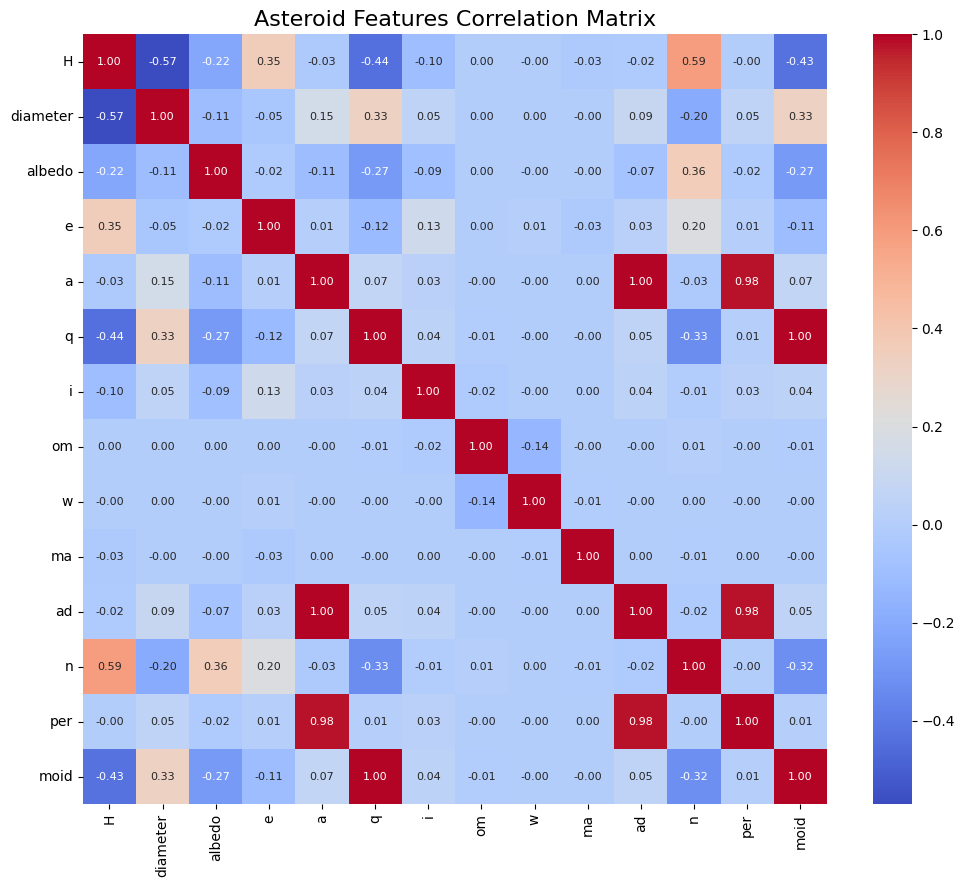

In [22]:
# Determine what collinearity and multicollinearity remains after dropping columns

plt.figure(figsize=(12, 10))

correlation_matrix = asteroids_df_clean.corr(numeric_only=True).round(2) # Remove pha from correlation matrix

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})

plt.title('Asteroid Features Correlation Matrix', fontsize=16)
plt.show()

In [23]:
# Check how many null numeric values exist

asteroids_df_clean.isnull().sum()

,0
neo,4
pha,19921
H,6263
diameter,822315
albedo,823421
e,0
a,0
q,0
i,0
om,0


In [24]:
# Determine amount of null albedo in dataset

albedo_null_count = len(asteroids_df_clean['albedo']) - len(asteroids_df_clean['albedo'].dropna()) # total rows - total rows with no null

print(f"{albedo_null_count} albedo rows are missing values.")
print(f"This represents {albedo_null_count/len(asteroids_df_clean):.2%} percent of the albedo column.")

823421 albedo rows are missing values.
This represents 85.91% percent of the albedo column.


In [25]:
# Drop albedo column because high number of nulls and doesn't relate to hypotheses

asteroids_df_clean = asteroids_df_clean.drop(columns=['albedo'])
asteroids_df_clean.shape

(958524, 15)

In [26]:
# Determine amount of null diameter in dataset

diameter_null_count = len(asteroids_df_clean['diameter']) - len(asteroids_df_clean['diameter'].dropna()) # total rows - total rows with no null

print(f"{diameter_null_count} diameter rows are missing values.")
print(f"This represents {diameter_null_count/len(asteroids_df_clean):.2%} percent of the diameter column.")

822315 diameter rows are missing values.
This represents 85.79% percent of the diameter column.


In [27]:
# Even though related to hypothesis, drop diameter column because too many to impute

asteroids_df_clean = asteroids_df_clean.drop(columns=['diameter'])
asteroids_df_clean.shape

(958524, 14)

In [28]:
# Drop null pha rows since target variable

asteroids_df_clean = asteroids_df_clean.dropna(subset=['pha'])
asteroids_df_clean.shape

(938603, 14)

In [29]:
# Drop very small amounts of null values in columns neo, ma, ad, and per

asteroids_df_clean = asteroids_df_clean.dropna(subset=['neo', 'ma', 'ad', 'per'])
asteroids_df_clean.shape

(938598, 14)

In [30]:
# Check how many nulls remain

asteroids_df_clean.isnull().sum()

,0
neo,0
pha,0
H,6262
e,0
a,0
q,0
i,0
om,0
w,0
ma,0


In [31]:
# Check distribution of neo

asteroids_df_clean['neo'].value_counts()

,count
neo,
N,915704
Y,22894


In [32]:
# Will only include NEO asteroids as part of our analysis

asteroids_df_neo = asteroids_df_clean[asteroids_df_clean['neo'] == 'Y'].copy()

In [33]:
# Check distribution of target variable in NEO-only dataset

asteroids_df_neo['pha'].value_counts()

,count
pha,
N,20828
Y,2066


In [34]:
# Check amount of nulls

asteroids_df_neo.isnull().sum()

,0
neo,0
pha,0
H,11
e,0
a,0
q,0
i,0
om,0
w,0
ma,0


In [35]:
# Drop null values for H since it's a small amount

asteroids_df_neo = asteroids_df_neo.dropna(subset=['H'])
asteroids_df_neo.shape

(22883, 14)

In [36]:
# Examine dataset

asteroids_df_neo.head(10)

,neo,pha,H,e,a,q,i,om,w,ma,ad,n,per,moid
full_name,,,,,,,,,,,,,,
433 Eros (1898 DQ),Y,N,10.4,0.222951,1.458046,1.132973,10.830543,304.299327,178.882294,271.071732,1.783119,0.559819,643.065402,0.148623
719 Albert (1911 MT),Y,N,15.4,0.546558,2.638602,1.196452,11.567485,183.866950,156.176338,140.273422,4.080752,0.229955,1565.522356,0.203482
887 Alinda (1918 DB),Y,N,13.8,0.570332,2.473737,1.062886,9.393854,110.434218,350.495585,294.579157,3.884588,0.253323,1421.113276,0.082217
1036 Ganymed (1924 TD),Y,N,9.4,0.533046,2.664725,1.244303,26.677643,215.546826,132.364631,4.817745,4.085146,0.226582,1588.828164,0.344956
1221 Amor (1932 EA1),Y,N,17.7,0.435285,1.919498,1.083970,11.876537,171.326998,26.694797,38.522409,2.755027,0.370615,971.359460,0.107451
1566 Icarus (1949 MA),Y,Y,16.9,0.827021,1.078169,0.186500,22.822113,87.997544,31.393344,192.083181,1.969838,0.880387,408.910857,0.034245
1580 Betulia (1950 KA),Y,N,14.7,0.487350,2.197150,1.126368,52.092070,62.297817,159.517948,195.072454,3.267932,0.302632,1189.564506,0.136136
1620 Geographos (1951 RA),Y,Y,15.3,0.335455,1.245667,0.827802,13.337043,337.186975,276.956068,235.112642,1.663532,0.708926,507.810053,0.030353
1627 Ivar (1929 SH),Y,N,12.7,0.396783,1.863273,1.123958,8.451870,133.119343,167.793462,256.506900,2.602588,0.387516,928.994502,0.111952


In [37]:
# since dataset has all NEOs -> can drop NEO flag

asteroids_df_neo = asteroids_df_neo.drop(columns=['neo'])
asteroids_df_neo.shape

(22883, 13)

In [38]:
# Check if any null values remain

asteroids_df_neo.isnull().sum()

,0
pha,0
H,0
e,0
a,0
q,0
i,0
om,0
w,0
ma,0
ad,0


### Encode the target variable

In [39]:
label_encoder = LabelEncoder()
asteroids_df_neo['pha'] = label_encoder.fit_transform(asteroids_df_neo['pha'])

In [40]:
# Check distribution of encoded target variable

# Original dataset was 99.8% non-PHAs / 0.2% PHAs

# Neo-only dataset is 91% non-PHAs / 9% PHAs

asteroids_df_neo['pha'].value_counts(normalize=True)

,proportion
pha,
0,0.909715
1,0.090285


### Set random_state as global variable

In [41]:
global RANDOM_STATE
RANDOM_STATE=1776

### Separate independent and dependent variables

In [42]:
X = asteroids_df_neo.drop(columns=['pha'])

In [43]:
y = asteroids_df_neo['pha']

### Scale independent variables

In [44]:
# As discussed during office hours, in this class we can scale before splitting the data
# In real-world scenarios, this method could cause concern regarding data leakage

scaler = StandardScaler().set_output(transform='pandas') # option to output DataFrame
X_scaled = scaler.fit_transform(X)

### Display a sample row of the final independent variables

In [45]:
X.sample(1, random_state=RANDOM_STATE)

,H,e,a,q,i,om,w,ma,ad,n,per,moid
full_name,,,,,,,,,,,,
(2016 PJ38),21.1,0.297827,1.783331,1.252207,26.30813,314.92517,93.759592,151.298335,2.314455,0.413863,869.853785,0.486829


In [46]:
# Observe scaled data

X_scaled.sample(1, random_state=RANDOM_STATE)

,H,e,a,q,i,om,w,ma,ad,n,per,moid
full_name,,,,,,,,,,,,
(2016 PJ38),-0.592957,-0.826292,0.000318,1.454118,1.240635,1.375625,-0.846973,-0.168376,-0.069623,-0.373806,-0.008392,3.856556


### Display a sample row of the final dependent variable

In [47]:
y.sample(1, random_state=RANDOM_STATE)

,pha
full_name,
(2016 PJ38),0


### Split data into training and test sets

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, # Scaled independent variables
                                                    y, # dependent (target) variable
                                                    stratify = y, # Ensures test and training sets have same proportion of PHAs
                                                    test_size = 0.2, # 20% of dataset reserved for testing
                                                    random_state = RANDOM_STATE) # Used to reproduce results

## Baseline Model Training and Performance (with default hyperparameters)

### Train and evaluate Logistic Regression model (default hyperparameters)

In [49]:
# Create an instance of the model with random_state for reproducibility

lr_model = LogisticRegression(random_state=RANDOM_STATE)

In [50]:
# Show how long the training takes

%%time

# Train the model

lr_model.fit(X_train, y_train)

CPU times: user 54.5 ms, sys: 1.06 ms, total: 55.6 ms
Wall time: 57.7 ms


LogisticRegression(random_state=1776)

In [51]:
# Generate predictions against the scaled test set

y_lr_preds = lr_model.predict(X_test)

In [52]:
# Evaluate the Confusion Matrix

print('Logistic Regression Confusion Matrix\n')

lr_cm = confusion_matrix(y_test, y_lr_preds)

lr_cm_display = pd.DataFrame(lr_cm,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

lr_cm_display

Logistic Regression Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,4098,66
Actual PHAs,120,293


In [53]:
# Evaluate the Classification Report

print('Logistic Regression Classification Report\n')
print(classification_report(y_test,
                            y_lr_preds,
                            target_names=['Safe', 'PHAs']))

Logistic Regression Classification Report

              precision    recall  f1-score   support

        Safe       0.97      0.98      0.98      4164
        PHAs       0.82      0.71      0.76       413

    accuracy                           0.96      4577
   macro avg       0.89      0.85      0.87      4577
weighted avg       0.96      0.96      0.96      4577



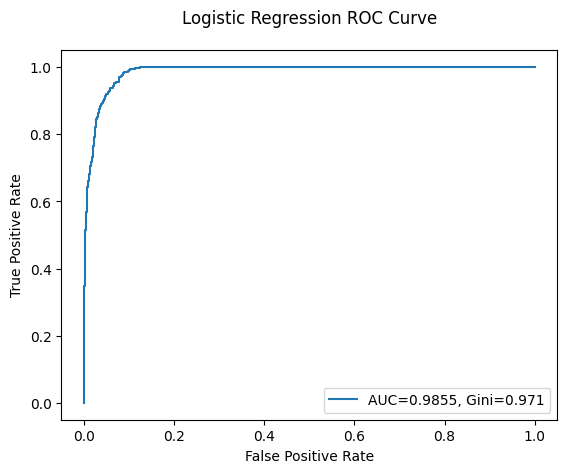

In [54]:
# Calculate the probability of each class for each data instance

y_lr_preds_prob = lr_model.predict_proba(X_test)[::,1]

# Display the ROC curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_lr_preds_prob)
auc_lr = round(roc_auc_score(y_test, y_lr_preds_prob), 4)
gini_lr = round(((auc_lr * 2) - 1), 4)
label_string = f'AUC={auc_lr}, Gini={gini_lr}'
plt.plot(fpr_lr, tpr_lr, label=label_string)
plt.legend(loc = 4)
plt.title('Logistic Regression ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Train and evaluate K-Nearest Neighbors model (default hyperparameters)

In [55]:
# Create an instance of the model; KNN does not need to use random_state for reproducibility

knn_model = KNeighborsClassifier()

In [56]:
# Show how long the training takes

%%time

# Train the model

knn_model.fit(X_train, y_train)

CPU times: user 30.8 ms, sys: 0 ns, total: 30.8 ms
Wall time: 32.4 ms


KNeighborsClassifier()

In [57]:
# Generate predictions against the scaled test set

y_knn_preds = knn_model.predict(X_test)

In [58]:
# Evaluate the Confusion Matrix

print('K-Nearest Neighbors Confusion Matrix\n')

knn_cm = confusion_matrix(y_test, y_knn_preds)

knn_cm_display = pd.DataFrame(knn_cm,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

knn_cm_display

K-Nearest Neighbors Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,4086,78
Actual PHAs,176,237


In [59]:
# Evaluate the Classification Report

print('K-Nearest Neighbors Classification Report\n')
print(classification_report(y_test,
                            y_knn_preds,
                            target_names=['Safe', 'PHAs']))

K-Nearest Neighbors Classification Report

              precision    recall  f1-score   support

        Safe       0.96      0.98      0.97      4164
        PHAs       0.75      0.57      0.65       413

    accuracy                           0.94      4577
   macro avg       0.86      0.78      0.81      4577
weighted avg       0.94      0.94      0.94      4577



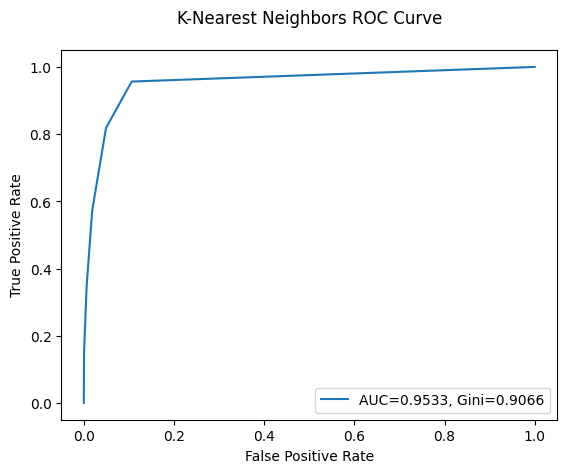

In [60]:
# Calculate the probability of each class for each data instance

y_knn_preds_prob = knn_model.predict_proba(X_test)[::,1]

# Display the ROC curve

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_preds_prob)
auc_knn = round(roc_auc_score(y_test, y_knn_preds_prob), 4)
gini_knn = round(((auc_knn * 2) - 1), 4)
label_string = f'AUC={auc_knn}, Gini={gini_knn}'
plt.plot(fpr_knn, tpr_knn, label=label_string)
plt.legend(loc = 4)
plt.title('K-Nearest Neighbors ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Train and evaluate Support Vector Machine model (default hyperparameters)

In [61]:
# Create an instance of the model with random_state for reproducibility

svm_model = SVC(random_state=RANDOM_STATE)

In [62]:
# Show how long the training takes

%%time

# Train the model

svm_model.fit(X_train, y_train)

CPU times: user 985 ms, sys: 0 ns, total: 985 ms
Wall time: 991 ms


SVC(random_state=1776)

In [63]:
# Generate predictions against the scaled test set

y_svm_preds = svm_model.predict(X_test)

In [64]:
# Evaluate the Confusion Matrix

print('Support Vector Machine Confusion Matrix\n')

svm_cm = confusion_matrix(y_test, y_svm_preds)

svm_cm_display = pd.DataFrame(svm_cm,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

svm_cm_display

Support Vector Machine Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,4129,35
Actual PHAs,84,329


In [65]:
# Evaluate the Classification Report

print('Support Vector Machine Classification Report\n')
print(classification_report(y_test,
                            y_svm_preds,
                            target_names=['Safe', 'PHAs']))

Support Vector Machine Classification Report

              precision    recall  f1-score   support

        Safe       0.98      0.99      0.99      4164
        PHAs       0.90      0.80      0.85       413

    accuracy                           0.97      4577
   macro avg       0.94      0.89      0.92      4577
weighted avg       0.97      0.97      0.97      4577



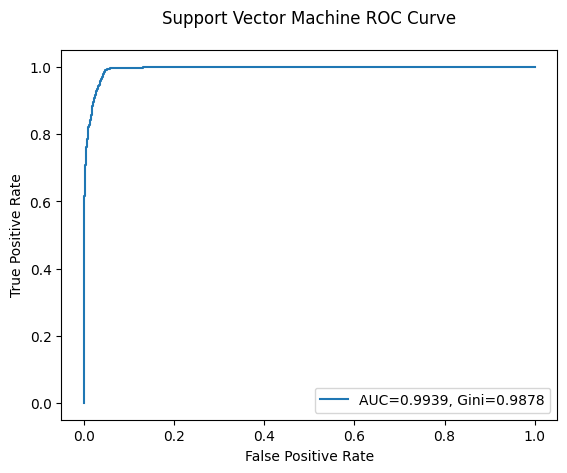

In [66]:
# Calculate the probability of each class for each data instance

y_svm_preds_prob = svm_model.decision_function(X_test) # .predict_proba doesn't work

# Display the ROC curve

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_svm_preds_prob)
auc_svm = round(roc_auc_score(y_test, y_svm_preds_prob), 4)
gini_svm = round(((auc_svm * 2) - 1), 4)
label_string = f'AUC={auc_svm}, Gini={gini_svm}'
plt.plot(fpr_svm, tpr_svm, label=label_string)
plt.legend(loc=4)
plt.title('Support Vector Machine ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Train and evaluate Random Forest model (default hyperparameters)

In [67]:
# Create an instance of the model with random_state for reproducibility

rf_model = RandomForestClassifier(random_state=RANDOM_STATE)

In [68]:
# Show how long the training takes

%%time

# Train the model

rf_model.fit(X_train, y_train)

CPU times: user 2.92 s, sys: 2.07 ms, total: 2.92 s
Wall time: 2.93 s


RandomForestClassifier(random_state=1776)

In [69]:
# Generate predictions against the scaled test set

y_rf_preds = rf_model.predict(X_test)

In [70]:
# Evaluate the Confusion Matrix

print('Random Forest Confusion Matrix\n')

rf_cm = confusion_matrix(y_test, y_rf_preds)

rf_cm_display = pd.DataFrame(rf_cm,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

rf_cm_display

Random Forest Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,4153,11
Actual PHAs,3,410


In [71]:
# Evaluate the Classification Report

print('Random Forest Classification Report\n')
print(classification_report(y_test,
                            y_rf_preds,
                            target_names=['Safe', 'PHAs']))

Random Forest Classification Report

              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      4164
        PHAs       0.97      0.99      0.98       413

    accuracy                           1.00      4577
   macro avg       0.99      1.00      0.99      4577
weighted avg       1.00      1.00      1.00      4577



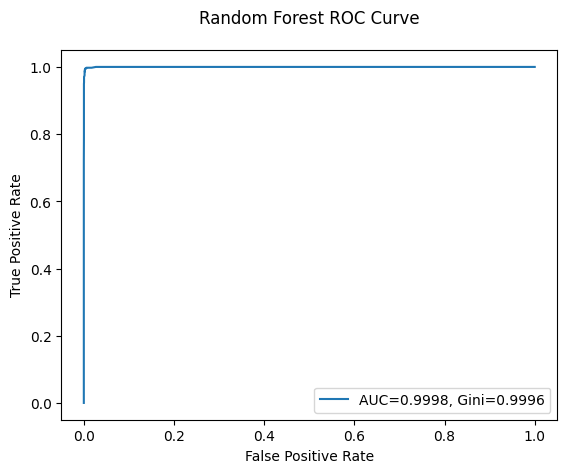

In [72]:
# Calculate the probability of each class for each data instance

y_rf_preds_prob = rf_model.predict_proba(X_test)[::,1]

# Display the ROC curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_rf_preds_prob)
auc_rf = round(roc_auc_score(y_test, y_rf_preds_prob), 4)
gini_rf = round(((auc_rf * 2) - 1), 4)
label_string = f'AUC={auc_rf}, Gini={gini_rf}'
plt.plot(fpr_rf, tpr_rf, label=label_string)
plt.legend(loc=4)
plt.title('Random Forest ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Combining the ROC Curve into one chart (Baseline)

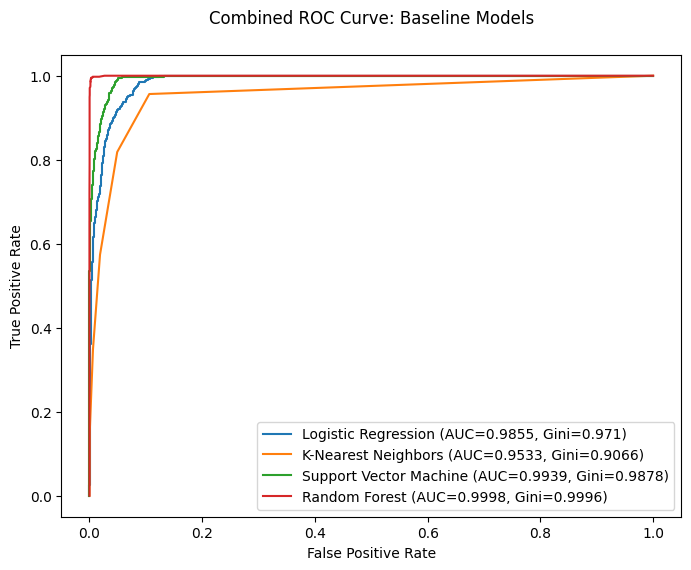

In [73]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr}, Gini={gini_lr})')
plt.plot(fpr_knn, tpr_knn, label=f'K-Nearest Neighbors (AUC={auc_knn}, Gini={gini_knn})')
plt.plot(fpr_svm, tpr_svm, label=f'Support Vector Machine (AUC={auc_svm}, Gini={gini_svm})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf}, Gini={gini_rf})')

plt.legend(loc=4)
plt.title('Combined ROC Curve: Baseline Models', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Retrain Models with Hyperparameter Tuning

### Train and evaluate revised Logistic Regression model

In [74]:
# Get default hyperparameters for model

lr_model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 1776,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [75]:
# Get more information about hyperparameter options

#help(LogisticRegression)

In [76]:
lr_model_v2 = LogisticRegression(random_state=RANDOM_STATE,
                                 class_weight='balanced') # to deal with class imbalance

In [77]:
%%time

lr_model_v2.fit(X_train, y_train)

CPU times: user 38.9 ms, sys: 0 ns, total: 38.9 ms
Wall time: 24.5 ms


LogisticRegression(class_weight='balanced', random_state=1776)

In [78]:
# Generate predictions against the scaled test set

y_lr_preds_v2 = lr_model_v2.predict(X_test)

In [79]:
print('Logistic Regression Confusion Matrix\n')

lr_cm_v2 = confusion_matrix(y_test, y_lr_preds_v2)

lr_cm_display_v2 = pd.DataFrame(lr_cm_v2,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

lr_cm_display_v2

Logistic Regression Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,3879,285
Actual PHAs,16,397


In [80]:
print('Logistic Regression Classification Report\n')
print(classification_report(y_test,
                            y_lr_preds_v2,
                            target_names=['Safe', 'PHAs']))

Logistic Regression Classification Report

              precision    recall  f1-score   support

        Safe       1.00      0.93      0.96      4164
        PHAs       0.58      0.96      0.73       413

    accuracy                           0.93      4577
   macro avg       0.79      0.95      0.84      4577
weighted avg       0.96      0.93      0.94      4577



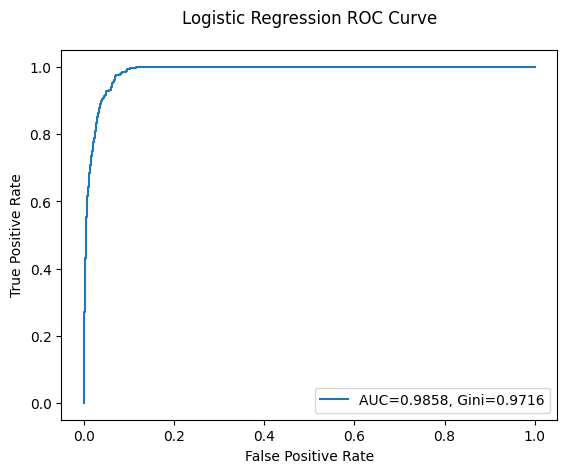

In [81]:
# Calculate the probability of each class for each data instance

y_lr_preds_prob_v2 = lr_model_v2.predict_proba(X_test)[::,1]

# Display the ROC curve

fpr_lr_v2, tpr_lr_v2, _ = roc_curve(y_test, y_lr_preds_prob_v2)
auc_lr_v2 = round(roc_auc_score(y_test, y_lr_preds_prob_v2), 4)
gini_lr_v2 = round(((auc_lr_v2 * 2) - 1), 4)
label_string = f'AUC={auc_lr_v2}, Gini={gini_lr_v2}'
plt.plot(fpr_lr_v2, tpr_lr_v2, label=label_string)
plt.legend(loc = 4)
plt.title('Logistic Regression ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Train and evaluate revised K-Nearest Neighbors model

In [82]:
# Get default hyperparameters for model

knn_model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [83]:
# Get more information about hyperparameter options

#help(KNeighborsClassifier)

In [84]:
# KNeighborsClassifier does not have a class_weight='balanced' hyperparameter

knn_model_v2 = KNeighborsClassifier(weights='distance') # to give closer neighbors more weight

In [85]:
%%time

knn_model_v2.fit(X_train, y_train)

CPU times: user 28.2 ms, sys: 0 ns, total: 28.2 ms
Wall time: 28.9 ms


KNeighborsClassifier(weights='distance')

In [86]:
y_knn_preds_v2 = knn_model_v2.predict(X_test)

In [87]:
print('K-Nearest Neighbors Confusion Matrix\n')

knn_cm_v2 = confusion_matrix(y_test, y_knn_preds_v2)

knn_cm_display_v2 = pd.DataFrame(knn_cm_v2,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

knn_cm_display_v2

K-Nearest Neighbors Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,4086,78
Actual PHAs,174,239


In [88]:
print('K-Nearest Neighbors Classification Report\n')
print(classification_report(y_test,
                            y_knn_preds_v2,
                            target_names=['Safe', 'PHAs']))

K-Nearest Neighbors Classification Report

              precision    recall  f1-score   support

        Safe       0.96      0.98      0.97      4164
        PHAs       0.75      0.58      0.65       413

    accuracy                           0.94      4577
   macro avg       0.86      0.78      0.81      4577
weighted avg       0.94      0.94      0.94      4577



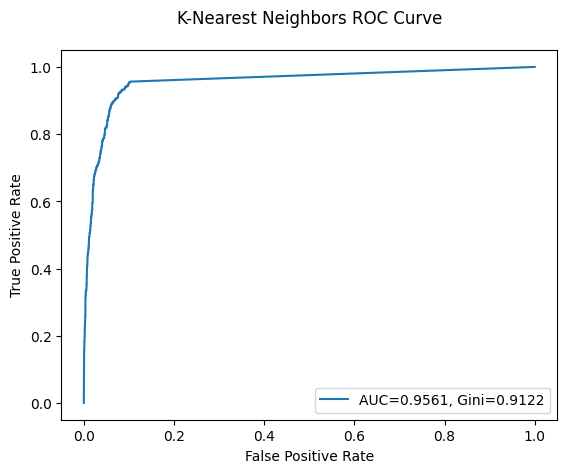

In [89]:
# Calculate the probability of each class for each data instance

y_knn_preds_prob_v2 = knn_model_v2.predict_proba(X_test)[::,1]

# Display the ROC curve

fpr_knn_v2, tpr_knn_v2, _ = roc_curve(y_test, y_knn_preds_prob_v2)
auc_knn_v2 = round(roc_auc_score(y_test, y_knn_preds_prob_v2), 4)
gini_knn_v2 = round(((auc_knn_v2 * 2) - 1), 4)
label_string = f'AUC={auc_knn_v2}, Gini={gini_knn_v2}'
plt.plot(fpr_knn_v2, tpr_knn_v2, label=label_string)
plt.legend(loc = 4)
plt.title('K-Nearest Neighbors ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Train and evaluate revised Support Vector Machine model

In [90]:
# Get default hyperparameters for model

svm_model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 1776,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [91]:
# Get more information about hyperparameter options

#help(SVC)

In [92]:
svm_model_v2 = SVC(random_state=RANDOM_STATE,
                   class_weight='balanced') # to deal with class imbalance

In [93]:
%%time

svm_model_v2.fit(X_train, y_train)

CPU times: user 2.1 s, sys: 23.9 ms, total: 2.12 s
Wall time: 2.16 s


SVC(class_weight='balanced', random_state=1776)

In [94]:
y_svm_preds_v2 = svm_model_v2.predict(X_test)

In [95]:
print('Support Vector Machine Confusion Matrix\n')

svm_cm_v2 = confusion_matrix(y_test, y_svm_preds_v2)

svm_cm_display_v2 = pd.DataFrame(svm_cm_v2,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

svm_cm_display_v2

Support Vector Machine Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,3933,231
Actual PHAs,7,406


In [96]:
print('Support Vector Machine Classification Report\n')
print(classification_report(y_test,
                            y_svm_preds_v2,
                            target_names=['Safe', 'PHAs']))

Support Vector Machine Classification Report

              precision    recall  f1-score   support

        Safe       1.00      0.94      0.97      4164
        PHAs       0.64      0.98      0.77       413

    accuracy                           0.95      4577
   macro avg       0.82      0.96      0.87      4577
weighted avg       0.97      0.95      0.95      4577



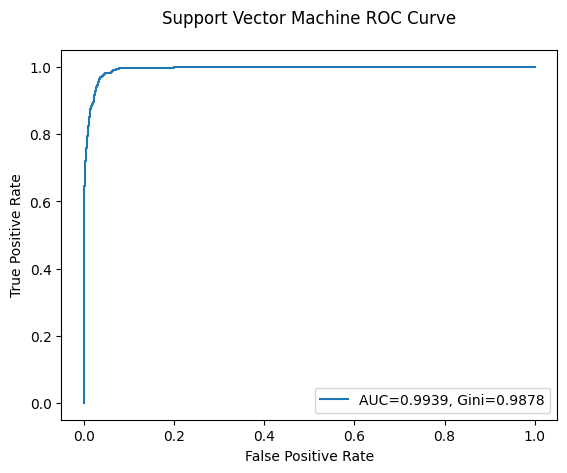

In [97]:
# Calculate the probability of each class for each data instance

y_svm_preds_prob_v2 = svm_model_v2.decision_function(X_test) # .predict_proba doesn't work

# Display the ROC curve

fpr_svm_v2, tpr_svm_v2, _ = roc_curve(y_test, y_svm_preds_prob_v2)
auc_svm_v2 = round(roc_auc_score(y_test, y_svm_preds_prob_v2), 4)
gini_svm_v2 = round(((auc_svm_v2 * 2) - 1), 4)
label_string = f'AUC={auc_svm_v2}, Gini={gini_svm_v2}'
plt.plot(fpr_svm_v2, tpr_svm_v2, label=label_string)
plt.legend(loc=4)
plt.title('Support Vector Machine ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Train and evaluate revised Random Forest model

In [98]:
# Get default hyperparameters for model

rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 1776,
 'verbose': 0,
 'warm_start': False}

In [99]:
# Get more information about hyperparameter options

#help(RandomForestClassifier)

In [100]:
rf_model_v2 = RandomForestClassifier(random_state=RANDOM_STATE,
                                     class_weight='balanced', # to deal with class imbalance
                                     max_depth=5) # to limit the model's decision tree depth

In [101]:
# Show how long the training takes

%%time

# Train the model

rf_model_v2.fit(X_train, y_train)

CPU times: user 2.33 s, sys: 2.46 ms, total: 2.33 s
Wall time: 2.34 s


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=1776)

In [102]:
# Generate predictions against the scaled test set

y_rf_preds_v2 = rf_model_v2.predict(X_test)

In [103]:
# Evaluate the Confusion Matrix

print('Random Forest Confusion Matrix\n')

rf_cm_v2 = confusion_matrix(y_test, y_rf_preds_v2)

rf_cm_display_v2 = pd.DataFrame(rf_cm_v2,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

rf_cm_display_v2

Random Forest Confusion Matrix



,Predicted Safe,Predicted PHAs
Actual Safe,4138,26
Actual PHAs,1,412


In [104]:
# Evaluate the Classification Report

print('Random Forest Classification Report\n')
print(classification_report(y_test,
                            y_rf_preds_v2,
                            target_names=['Safe', 'PHAs']))

Random Forest Classification Report

              precision    recall  f1-score   support

        Safe       1.00      0.99      1.00      4164
        PHAs       0.94      1.00      0.97       413

    accuracy                           0.99      4577
   macro avg       0.97      1.00      0.98      4577
weighted avg       0.99      0.99      0.99      4577



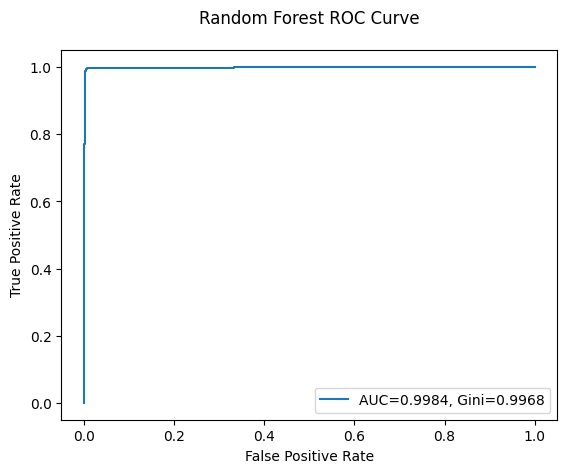

In [105]:
# Calculate the probability of each class for each data instance

y_rf_preds_prob_v2 = rf_model_v2.predict_proba(X_test)[::,1]

# Display the ROC curve

fpr_rf_v2, tpr_rf_v2, _ = roc_curve(y_test, y_rf_preds_prob_v2)
auc_rf_v2 = round(roc_auc_score(y_test, y_rf_preds_prob_v2), 4)
gini_rf_v2 = round(((auc_rf_v2 * 2) - 1), 4)
label_string = f'AUC={auc_rf_v2}, Gini={gini_rf_v2}'
plt.plot(fpr_rf_v2, tpr_rf_v2, label=label_string)
plt.legend(loc=4)
plt.title('Random Forest ROC Curve', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Combining the ROC Charts into one graph (Retrained)

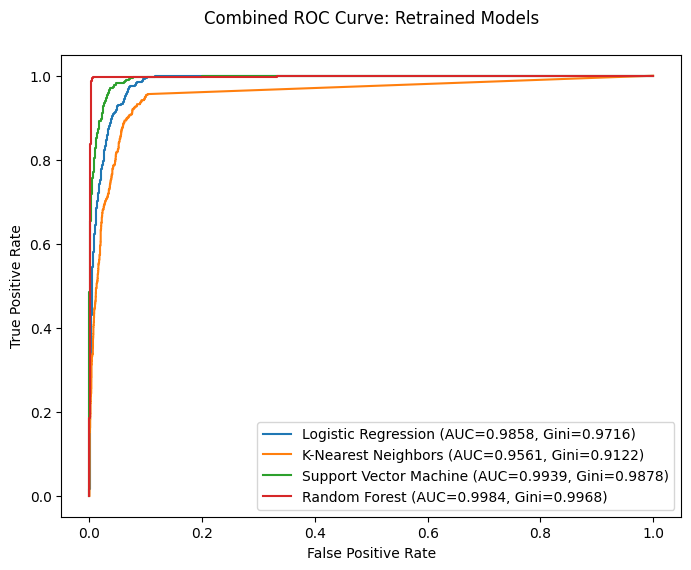

In [106]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr_v2, tpr_lr_v2, label=f'Logistic Regression (AUC={auc_lr_v2}, Gini={gini_lr_v2})')
plt.plot(fpr_knn_v2, tpr_knn_v2, label=f'K-Nearest Neighbors (AUC={auc_knn_v2}, Gini={gini_knn_v2})')
plt.plot(fpr_svm_v2, tpr_svm_v2, label=f'Support Vector Machine (AUC={auc_svm_v2}, Gini={gini_svm_v2})')
plt.plot(fpr_rf_v2, tpr_rf_v2, label=f'Random Forest (AUC={auc_rf_v2}, Gini={gini_rf_v2})')

plt.legend(loc=4)
plt.title('Combined ROC Curve: Retrained Models', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Model Accuracy, Precision, and Recall performance before and after training

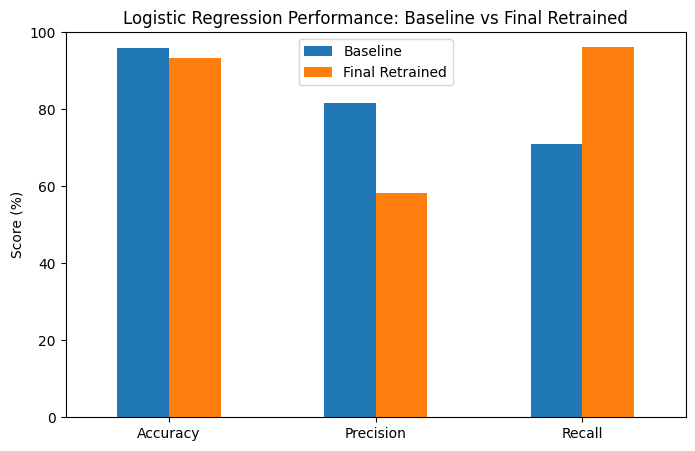

In [107]:
# Logistic Regression model bar graph

metrics_df = pd.DataFrame({
    "Baseline": [
        accuracy_score(y_test, y_lr_preds),
        precision_score(y_test, y_lr_preds),
        recall_score(y_test, y_lr_preds)
    ],
    "Final Retrained": [
        accuracy_score(y_test, y_lr_preds_v2),
        precision_score(y_test, y_lr_preds_v2),
        recall_score(y_test, y_lr_preds_v2)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("Logistic Regression Performance: Baseline vs Final Retrained")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

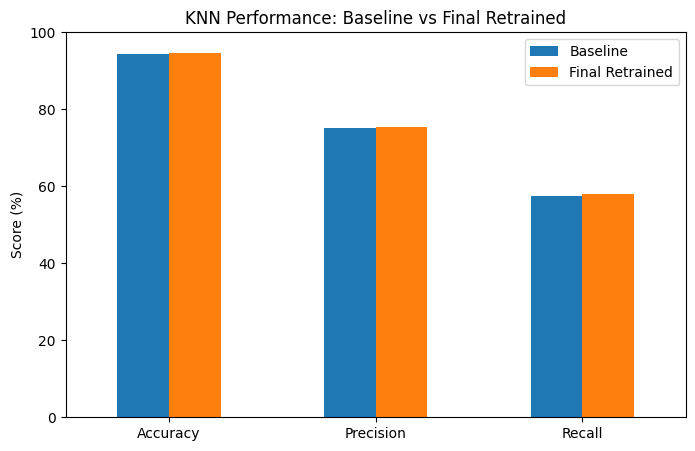

In [108]:
# KNN model bar graph

metrics_df = pd.DataFrame({
    "Baseline": [
        accuracy_score(y_test, y_knn_preds),
        precision_score(y_test, y_knn_preds),
        recall_score(y_test, y_knn_preds)
    ],
    "Final Retrained": [
        accuracy_score(y_test, y_knn_preds_v2),
        precision_score(y_test, y_knn_preds_v2),
        recall_score(y_test, y_knn_preds_v2)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("KNN Performance: Baseline vs Final Retrained")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

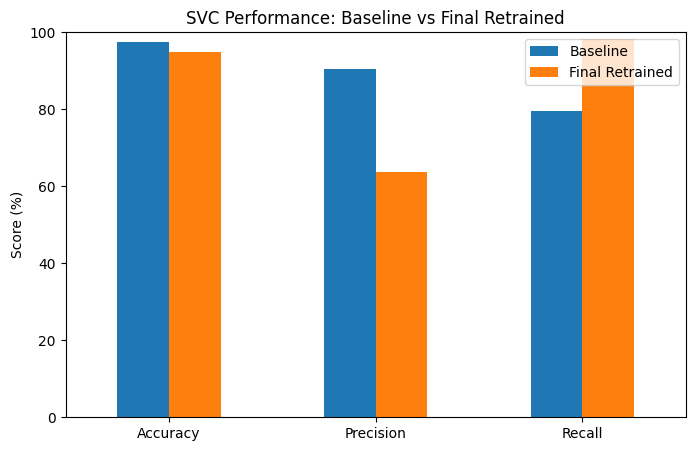

In [109]:
# SVC model bargraph

metrics_df = pd.DataFrame({
    "Baseline": [
        accuracy_score(y_test, y_svm_preds),
        precision_score(y_test, y_svm_preds),
        recall_score(y_test, y_svm_preds)
    ],
    "Final Retrained": [
        accuracy_score(y_test, y_svm_preds_v2),
        precision_score(y_test, y_svm_preds_v2),
        recall_score(y_test, y_svm_preds_v2)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("SVC Performance: Baseline vs Final Retrained")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

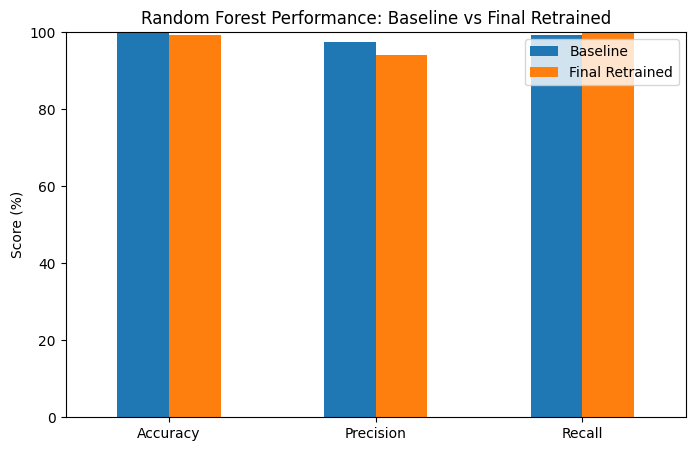

In [110]:
# Random Forest model bar graph

metrics_df = pd.DataFrame({
    "Baseline": [
        accuracy_score(y_test, y_rf_preds),
        precision_score(y_test, y_rf_preds),
        recall_score(y_test, y_rf_preds)
    ],
    "Final Retrained": [
        accuracy_score(y_test, y_rf_preds_v2),
        precision_score(y_test, y_rf_preds_v2),
        recall_score(y_test, y_rf_preds_v2)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("Random Forest Performance: Baseline vs Final Retrained")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

## Combined Model Accuracy, Precision, and Recall performance before and after training

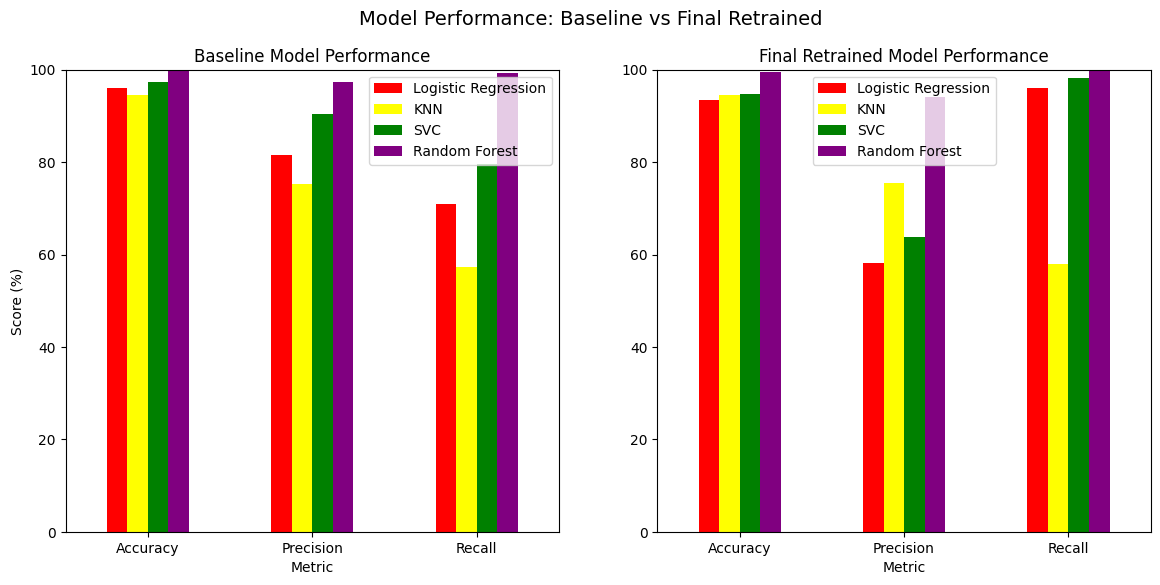

In [111]:
# Combined model performance bar graph

# [AI Start] - Prompted AI to help declutter and better visualize the graph

# Two-panel bar chart: Baseline vs Final Retrained

baseline_metrics = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_lr_preds),
        precision_score(y_test, y_lr_preds),
        recall_score(y_test, y_lr_preds)
    ],
    "KNN": [
        accuracy_score(y_test, y_knn_preds),
        precision_score(y_test, y_knn_preds),
        recall_score(y_test, y_knn_preds)
    ],
    "SVC": [
        accuracy_score(y_test, y_svm_preds),
        precision_score(y_test, y_svm_preds),
        recall_score(y_test, y_svm_preds)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_rf_preds),
        precision_score(y_test, y_rf_preds),
        recall_score(y_test, y_rf_preds)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

retrained_metrics = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_lr_preds_v2),
        precision_score(y_test, y_lr_preds_v2),
        recall_score(y_test, y_lr_preds_v2)
    ],
    "KNN": [
        accuracy_score(y_test, y_knn_preds_v2),
        precision_score(y_test, y_knn_preds_v2),
        recall_score(y_test, y_knn_preds_v2)
    ],
    "SVC": [
        accuracy_score(y_test, y_svm_preds_v2),
        precision_score(y_test, y_svm_preds_v2),
        recall_score(y_test, y_svm_preds_v2)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_rf_preds_v2),
        precision_score(y_test, y_rf_preds_v2),
        recall_score(y_test, y_rf_preds_v2)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

baseline_metrics.plot(kind="bar", ax=axes[0], color =['Red', 'Yellow', 'Green', 'Purple'])
axes[0].set_title("Baseline Model Performance")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score (%)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis = 'x', rotation=0)

retrained_metrics.plot(kind="bar", ax=axes[1], color =['Red', 'Yellow', 'Green', 'Purple'])
axes[1].set_title("Final Retrained Model Performance")
axes[1].set_xlabel("Metric")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis = 'x', rotation=0)

fig.suptitle("Model Performance: Baseline vs Final Retrained", fontsize=14)
plt.show()

# [AI End]

## Evaluate Feature Importance

In [112]:
# Get the feature names

feature_names = X.columns
feature_names

Index(['H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'moid'], dtype='object')

In [113]:
# Get the feature importances for the features above

# Use method available for Random Forest

feature_importances = rf_model_v2.feature_importances_
feature_importances

array([0.44125249, 0.03623425, 0.00505179, 0.12328053, 0.01913045,
       0.00095916, 0.00335179, 0.010447  , 0.00255739, 0.0050241 ,
       0.00802684, 0.34468421])

In [114]:
# Create the feature evaluation DataFrame

feature_evaluation_df = pd.DataFrame({'Feature': feature_names,
                                      'Importance': feature_importances
                                      })

# Set the feature name as the index

feature_evaluation_df = feature_evaluation_df.set_index('Feature')

# Sort the values by feature importance

feature_evaluation_df = feature_evaluation_df.sort_values('Importance', ascending=False)

# Display the feature evaluation

feature_evaluation_df

,Importance
Feature,
H,0.441252
moid,0.344684
q,0.123281
e,0.036234
i,0.019130
ma,0.010447
per,0.008027
a,0.005052
n,0.005024


## Feature Ablation Study: Remove H from Dataset

In [115]:
# Drop H from the scaled data
# Can do this since each column is scaled independently by StandardScaler

X_scaled_no_H = X_scaled.drop(columns='H')
X_scaled_no_H

,e,a,q,i,om,w,ma,ad,n,per,moid
full_name,,,,,,,,,,,
433 Eros (1898 DQ),-1.249574,-0.133711,0.941638,-0.151295,1.272938,-0.029893,0.819897,-0.179470,0.146178,-0.022539,0.542431
719 Albert (1911 MT),0.579824,0.352719,1.214477,-0.085020,0.109091,-0.247844,-0.259344,0.295534,-1.028996,0.035004,1.080001
887 Alinda (1918 DB),0.714218,0.284789,0.640401,-0.280499,-0.600556,1.617398,1.013861,0.254980,-0.945748,0.025996,-0.108291
1036 Ganymed (1924 TD),0.503437,0.363482,1.420148,1.273866,0.415242,-0.476409,-1.377014,0.296442,-1.041013,0.036458,2.466324
1221 Amor (1932 EA1),-0.049222,0.056423,0.731019,-0.057227,-0.012094,-1.490718,-1.098911,0.021459,-0.527882,-0.002060,0.138981
...,...,...,...,...,...,...,...,...,...,...,...
(2020 KM4),-1.248392,-0.210403,0.318845,-0.577257,-1.043771,0.312283,1.401864,-0.226474,0.599619,-0.029970,-0.861231
(2020 KN4),-0.858656,-0.298013,-0.704990,1.981516,0.727519,0.647730,-0.787701,-0.265144,1.372483,-0.037813,-0.346471
(2020 KO4),0.699723,0.161860,0.113400,-0.803411,-1.038171,0.369528,1.460636,0.156970,-0.753861,0.010452,-0.875778


In [116]:
X_train_no_H, X_test_no_H, y_train, y_test = train_test_split(X_scaled_no_H, # Scaled independent variables without H
                                                              y, # dependent (target) variable
                                                              stratify = y, # Ensures test and training sets have same proportion of PHAs
                                                              test_size = 0.2, # 20% of dataset reserved for testing
                                                              random_state = RANDOM_STATE) # Used to reproduce results

### Train and evaluate Random Forest model (without H)

In [117]:
rf_model_v3 = RandomForestClassifier(random_state=RANDOM_STATE,
                                     class_weight='balanced', # to deal with class imbalance
                                     max_depth=5) # to limit the model's decision tree depth

In [118]:
# Show how long the training takes

%%time

# Train the model without H

rf_model_v3.fit(X_train_no_H, y_train)

CPU times: user 2.54 s, sys: 3.66 ms, total: 2.54 s
Wall time: 2.55 s


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=1776)

In [119]:
# Generate predictions against the scaled test set without H

y_rf_preds_v3 = rf_model_v3.predict(X_test_no_H)

In [120]:
# Evaluate the Confusion Matrix

print('Random Forest Classification Confusion Matrix (No H)\n')

rf_cm_v3 = confusion_matrix(y_test, y_rf_preds_v3)

rf_cm_display_v3 = pd.DataFrame(rf_cm_v3,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

rf_cm_display_v3

Random Forest Classification Confusion Matrix (No H)



,Predicted Safe,Predicted PHAs
Actual Safe,2939,1225
Actual PHAs,17,396


In [121]:
# Evaluate the Classification Report (No H)

print('Random Forest Classification Report (No H)\n')
print(classification_report(y_test,
                            y_rf_preds_v3,
                            target_names=['Safe', 'PHAs']))

Random Forest Classification Report (No H)

              precision    recall  f1-score   support

        Safe       0.99      0.71      0.83      4164
        PHAs       0.24      0.96      0.39       413

    accuracy                           0.73      4577
   macro avg       0.62      0.83      0.61      4577
weighted avg       0.93      0.73      0.79      4577



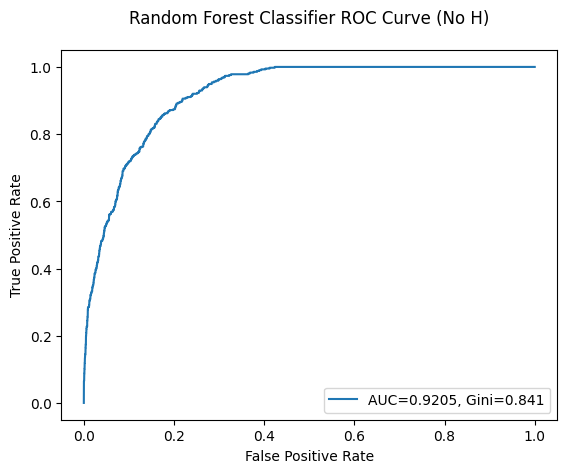

In [122]:
# Calculate the probability of each class for each data instance

y_rf_preds_prob_v3 = rf_model_v3.predict_proba(X_test_no_H)[::,1]

# Display the ROC curve

fpr_rf_v3, tpr_rf_v3, _ = roc_curve(y_test, y_rf_preds_prob_v3)
auc_rf_v3 = round(roc_auc_score(y_test, y_rf_preds_prob_v3), 4)
gini_rf_v3 = round(((auc_rf_v3 * 2) - 1), 4)
label_string = f'AUC={auc_rf_v3}, Gini={gini_rf_v3}'
plt.plot(fpr_rf_v3, tpr_rf_v3, label=label_string)
plt.legend(loc=4)
plt.title('Random Forest Classifier ROC Curve (No H)', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

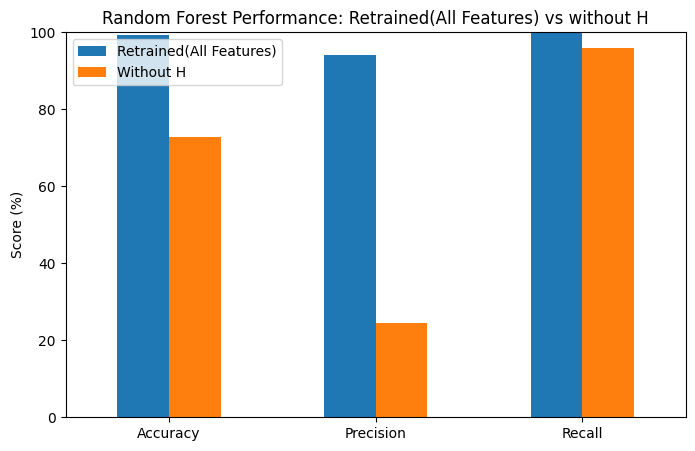

In [123]:
# Compare Random Forest performance with all features vs without H

metrics_df_v2 = pd.DataFrame({
    "Retrained(All Features)": [
        accuracy_score(y_test, y_rf_preds_v2),
        precision_score(y_test, y_rf_preds_v2),
        recall_score(y_test, y_rf_preds_v2)
    ],
    "Without H": [
        accuracy_score(y_test, y_rf_preds_v3),
        precision_score(y_test, y_rf_preds_v3),
        recall_score(y_test, y_rf_preds_v3)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df_v2.plot(kind="bar", figsize=(8,5))

plt.title("Random Forest Performance: Retrained(All Features) vs without H")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

### Train and evaluate Suport Vector Classifier model (without H)

In [124]:
svm_model_v3 = SVC(random_state=RANDOM_STATE,
                   class_weight='balanced') # to deal with class imbalance

In [125]:
# Show how long the training takes

%%time

# Train the model without H

svm_model_v3.fit(X_train_no_H, y_train)

CPU times: user 6.56 s, sys: 3.67 ms, total: 6.57 s
Wall time: 6.64 s


SVC(class_weight='balanced', random_state=1776)

In [126]:
# Generate predictions against the scaled test set without H

y_svm_preds_v3 = svm_model_v3.predict(X_test_no_H)

In [127]:
# Evaluate the Confusion Matrix

print('Support Vector Classification Confusion Matrix (No H)\n')

svm_cm_v3 = confusion_matrix(y_test, y_svm_preds_v3)

svm_cm_display_v3 = pd.DataFrame(svm_cm_v3,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

svm_cm_display_v3

Support Vector Classification Confusion Matrix (No H)



,Predicted Safe,Predicted PHAs
Actual Safe,3075,1089
Actual PHAs,52,361


In [128]:
# Evaluate the Classification Report (No H)

print('Support Vector Classification Report (No H)\n')
print(classification_report(y_test,
                            y_svm_preds_v3,
                            target_names=['Safe', 'PHAs']))

Support Vector Classification Report (No H)

              precision    recall  f1-score   support

        Safe       0.98      0.74      0.84      4164
        PHAs       0.25      0.87      0.39       413

    accuracy                           0.75      4577
   macro avg       0.62      0.81      0.62      4577
weighted avg       0.92      0.75      0.80      4577



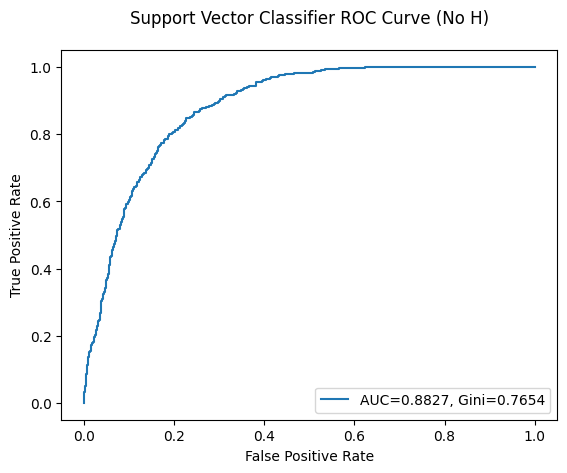

In [129]:
# Calculate the probability of each class for each data instance

y_svm_preds_prob_v3 = svm_model_v3.decision_function(X_test_no_H)

# Display the ROC curve

fpr_svm_v3, tpr_svm_v3, _ = roc_curve(y_test, y_svm_preds_prob_v3)
auc_svm_v3 = round(roc_auc_score(y_test, y_svm_preds_prob_v3), 4)
gini_svm_v3 = round(((auc_svm_v3 * 2) - 1), 4)
label_string = f'AUC={auc_svm_v3}, Gini={gini_svm_v3}'
plt.plot(fpr_svm_v3, tpr_svm_v3, label=label_string)
plt.legend(loc=4)
plt.title('Support Vector Classifier ROC Curve (No H)', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

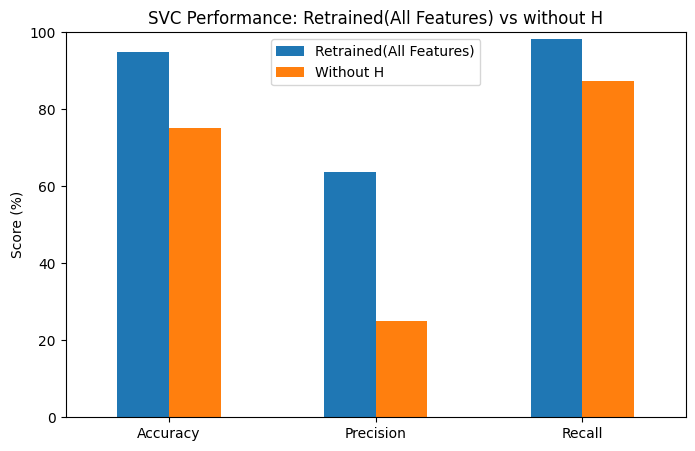

In [130]:
# Compare SVC performance with all features vs without H

metrics_df_v2 = pd.DataFrame({
    "Retrained(All Features)": [
        accuracy_score(y_test, y_svm_preds_v2),
        precision_score(y_test, y_svm_preds_v2),
        recall_score(y_test, y_svm_preds_v2)
    ],
    "Without H": [
        accuracy_score(y_test, y_svm_preds_v3),
        precision_score(y_test, y_svm_preds_v3),
        recall_score(y_test, y_svm_preds_v3)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df_v2.plot(kind="bar", figsize=(8,5))

plt.title("SVC Performance: Retrained(All Features) vs without H")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

## Feature Ablation Study: Remove moid from Dataset

In [131]:
# Drop moid from the scaled data
# Can do this since each column is scaled independently by StandardScaler

X_scaled_no_moid = X_scaled.drop(columns='moid')
X_scaled_no_moid

,H,e,a,q,i,om,w,ma,ad,n,per
full_name,,,,,,,,,,,
433 Eros (1898 DQ),-4.178066,-1.249574,-0.133711,0.941638,-0.151295,1.272938,-0.029893,0.819897,-0.179470,0.146178,-0.022539
719 Albert (1911 MT),-2.502781,0.579824,0.352719,1.214477,-0.085020,0.109091,-0.247844,-0.259344,0.295534,-1.028996,0.035004
887 Alinda (1918 DB),-3.038872,0.714218,0.284789,0.640401,-0.280499,-0.600556,1.617398,1.013861,0.254980,-0.945748,0.025996
1036 Ganymed (1924 TD),-4.513123,0.503437,0.363482,1.420148,1.273866,0.415242,-0.476409,-1.377014,0.296442,-1.041013,0.036458
1221 Amor (1932 EA1),-1.732151,-0.049222,0.056423,0.731019,-0.057227,-0.012094,-1.490718,-1.098911,0.021459,-0.527882,-0.002060
...,...,...,...,...,...,...,...,...,...,...,...
(2020 KM4),1.684759,-1.248392,-0.210403,0.318845,-0.577257,-1.043771,0.312283,1.401864,-0.226474,0.599619,-0.029970
(2020 KN4),-0.455584,-0.858656,-0.298013,-0.704990,1.981516,0.727519,0.647730,-0.787701,-0.265144,1.372483,-0.037813
(2020 KO4),1.377177,0.699723,0.161860,0.113400,-0.803411,-1.038171,0.369528,1.460636,0.156970,-0.753861,0.010452


In [132]:
X_train_no_moid, X_test_no_moid, y_train, y_test = train_test_split(X_scaled_no_moid, # Scaled independent variables without H and moid
                                                                    y, # dependent (target) variable
                                                                    stratify = y, # Ensures test and training sets have same proportion of PHAs
                                                                    test_size = 0.2, # 20% of dataset reserved for testing
                                                                    random_state = RANDOM_STATE) # Used to reproduce results

### Train and evaluate Random Forest model (without moid)

In [133]:
rf_model_v4 = RandomForestClassifier(random_state=RANDOM_STATE,
                                     class_weight='balanced', # to deal with class imbalance
                                     max_depth=5) # to limit the model's decision tree depth

In [134]:
# Show how long the training takes

%%time

# Train the model without moid

rf_model_v4.fit(X_train_no_moid, y_train)

CPU times: user 2.74 s, sys: 3.92 ms, total: 2.74 s
Wall time: 2.74 s


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=1776)

In [135]:
# Generate predictions against the scaled test set without moid

y_rf_preds_v4 = rf_model_v4.predict(X_test_no_moid)

In [136]:
# Evaluate the Confusion Matrix

print('Random Forest Classification Confusion Matrix (No moid)\n')

rf_cm_v4 = confusion_matrix(y_test, y_rf_preds_v4)

rf_cm_display_v4 = pd.DataFrame(rf_cm_v4,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

rf_cm_display_v4

Random Forest Classification Confusion Matrix (No moid)



,Predicted Safe,Predicted PHAs
Actual Safe,3461,703
Actual PHAs,4,409


In [137]:
# Evaluate the Classification Report (No moid)

print('Random Forest Classification Report (No moid)\n')
print(classification_report(y_test,
                            y_rf_preds_v4,
                            target_names=['Safe', 'PHAs']))

Random Forest Classification Report (No moid)

              precision    recall  f1-score   support

        Safe       1.00      0.83      0.91      4164
        PHAs       0.37      0.99      0.54       413

    accuracy                           0.85      4577
   macro avg       0.68      0.91      0.72      4577
weighted avg       0.94      0.85      0.87      4577



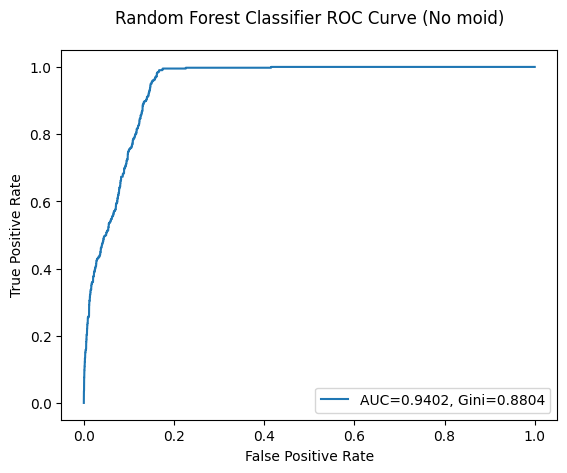

In [138]:
# Calculate the probability of each class for each data instance

y_rf_preds_prob_v4 = rf_model_v4.predict_proba(X_test_no_moid)[::,1]

# Display the ROC curve

fpr_rf_v4, tpr_rf_v4, _ = roc_curve(y_test, y_rf_preds_prob_v4)
auc_rf_v4 = round(roc_auc_score(y_test, y_rf_preds_prob_v4), 4)
gini_rf_v4 = round(((auc_rf_v4 * 2) - 1), 4)
label_string = f'AUC={auc_rf_v4}, Gini={gini_rf_v4}'
plt.plot(fpr_rf_v4, tpr_rf_v4, label=label_string)
plt.legend(loc=4)
plt.title('Random Forest Classifier ROC Curve (No moid)', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

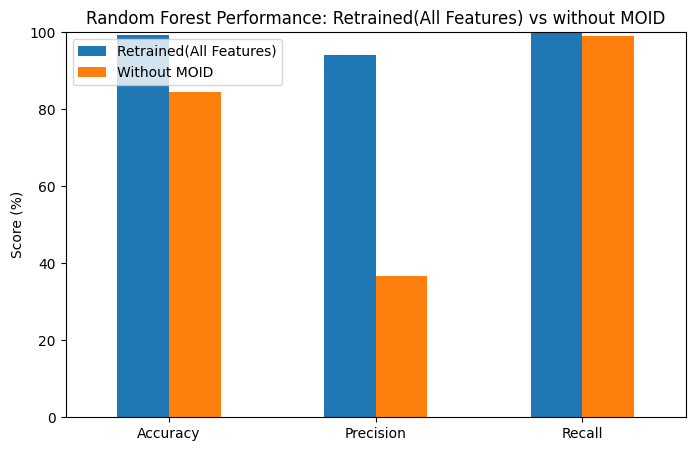

In [139]:
# Compare Random Forest performance with all features vs without MOID

metrics_df_v2 = pd.DataFrame({
    "Retrained(All Features)": [
        accuracy_score(y_test, y_rf_preds_v2),
        precision_score(y_test, y_rf_preds_v2),
        recall_score(y_test, y_rf_preds_v2)
    ],
    "Without MOID": [
        accuracy_score(y_test, y_rf_preds_v4),
        precision_score(y_test, y_rf_preds_v4),
        recall_score(y_test, y_rf_preds_v4)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df_v2.plot(kind="bar", figsize=(8,5))

plt.title("Random Forest Performance: Retrained(All Features) vs without MOID")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

### Train and evaluate Suport Vector Classifier model (without moid)

In [140]:
svm_model_v4 = SVC(random_state=RANDOM_STATE,
                   class_weight='balanced') # to deal with class imbalance

In [141]:
# Show how long the training takes

%%time

# Train the model without moid

svm_model_v4.fit(X_train_no_moid, y_train)

CPU times: user 4.67 s, sys: 1.26 ms, total: 4.67 s
Wall time: 4.73 s


SVC(class_weight='balanced', random_state=1776)

In [142]:
# Generate predictions against the scaled test set without moid

y_svm_preds_v4 = svm_model_v4.predict(X_test_no_moid)

In [143]:
# Evaluate the Confusion Matrix

print('Support Vector Classification Confusion Matrix (No moid)\n')

svm_cm_v4 = confusion_matrix(y_test, y_svm_preds_v4)

svm_cm_display_v4 = pd.DataFrame(svm_cm_v4,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

svm_cm_display_v4

Support Vector Classification Confusion Matrix (No moid)



,Predicted Safe,Predicted PHAs
Actual Safe,3349,815
Actual PHAs,18,395


In [144]:
# Evaluate the Classification Report (No moid)

print('Support Vector Classification Report (No moid)\n')
print(classification_report(y_test,
                            y_svm_preds_v4,
                            target_names=['Safe', 'PHAs']))

Support Vector Classification Report (No moid)

              precision    recall  f1-score   support

        Safe       0.99      0.80      0.89      4164
        PHAs       0.33      0.96      0.49       413

    accuracy                           0.82      4577
   macro avg       0.66      0.88      0.69      4577
weighted avg       0.93      0.82      0.85      4577



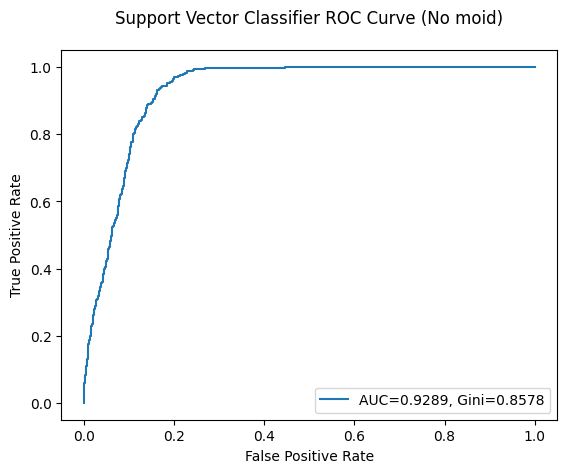

In [145]:
# Calculate the probability of each class for each data instance

y_svm_preds_prob_v4 = svm_model_v4.decision_function(X_test_no_moid)

# Display the ROC curve

fpr_svm_v4, tpr_svm_v4, _ = roc_curve(y_test, y_svm_preds_prob_v4)
auc_svm_v4 = round(roc_auc_score(y_test, y_svm_preds_prob_v4), 4)
gini_svm_v4 = round(((auc_svm_v4 * 2) - 1), 4)
label_string = f'AUC={auc_svm_v4}, Gini={gini_svm_v4}'
plt.plot(fpr_svm_v4, tpr_svm_v4, label=label_string)
plt.legend(loc=4)
plt.title('Support Vector Classifier ROC Curve (No moid)', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

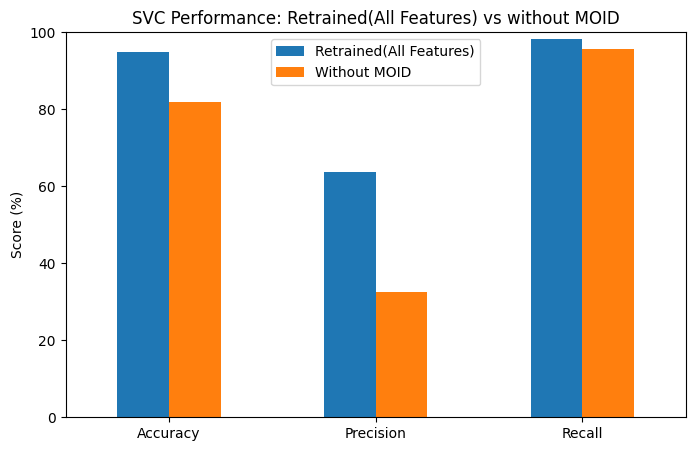

In [146]:
# Compare SVC performance with all features vs without MOID

metrics_df_v2 = pd.DataFrame({
    "Retrained(All Features)": [
        accuracy_score(y_test, y_svm_preds_v2),
        precision_score(y_test, y_svm_preds_v2),
        recall_score(y_test, y_svm_preds_v2)
    ],
    "Without MOID": [
        accuracy_score(y_test, y_svm_preds_v4),
        precision_score(y_test, y_svm_preds_v4),
        recall_score(y_test, y_svm_preds_v4)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df_v2.plot(kind="bar", figsize=(8,5))

plt.title("SVC Performance: Retrained(All Features) vs without MOID")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

##Feature Ablation Study: Remove H and moid from Dataset

In [147]:
# Drop H and moid from the scaled data
# Can do this since each column is scaled independently by StandardScaler

X_scaled_no_H_moid = X_scaled.drop(columns=['H', 'moid'])
X_scaled_no_H_moid

,e,a,q,i,om,w,ma,ad,n,per
full_name,,,,,,,,,,
433 Eros (1898 DQ),-1.249574,-0.133711,0.941638,-0.151295,1.272938,-0.029893,0.819897,-0.179470,0.146178,-0.022539
719 Albert (1911 MT),0.579824,0.352719,1.214477,-0.085020,0.109091,-0.247844,-0.259344,0.295534,-1.028996,0.035004
887 Alinda (1918 DB),0.714218,0.284789,0.640401,-0.280499,-0.600556,1.617398,1.013861,0.254980,-0.945748,0.025996
1036 Ganymed (1924 TD),0.503437,0.363482,1.420148,1.273866,0.415242,-0.476409,-1.377014,0.296442,-1.041013,0.036458
1221 Amor (1932 EA1),-0.049222,0.056423,0.731019,-0.057227,-0.012094,-1.490718,-1.098911,0.021459,-0.527882,-0.002060
...,...,...,...,...,...,...,...,...,...,...
(2020 KM4),-1.248392,-0.210403,0.318845,-0.577257,-1.043771,0.312283,1.401864,-0.226474,0.599619,-0.029970
(2020 KN4),-0.858656,-0.298013,-0.704990,1.981516,0.727519,0.647730,-0.787701,-0.265144,1.372483,-0.037813
(2020 KO4),0.699723,0.161860,0.113400,-0.803411,-1.038171,0.369528,1.460636,0.156970,-0.753861,0.010452


In [148]:
X_train_no_H_moid, X_test_no_H_moid, y_train, y_test = train_test_split(X_scaled_no_H_moid, # Scaled independent variables without H and moid
                                                                        y, # dependent (target) variable
                                                                        stratify = y, # Ensures test and training sets have same proportion of PHAs
                                                                        test_size = 0.2, # 20% of dataset reserved for testing
                                                                        random_state = RANDOM_STATE) # Used to reproduce results

### Train and evaluate Random Forest model (without H and moid)

In [149]:
rf_model_v5 = RandomForestClassifier(random_state=RANDOM_STATE,
                                     class_weight='balanced', # to deal with class imbalance
                                     max_depth=5) # to limit the model's decision tree depth

In [150]:
# Show how long the training takes

%%time

# Train the model without H and moid

rf_model_v5.fit(X_train_no_H_moid, y_train)

CPU times: user 3.03 s, sys: 2.84 ms, total: 3.03 s
Wall time: 3.03 s


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=1776)

In [151]:
# Generate predictions against the scaled test set without H and moid

y_rf_preds_v5 = rf_model_v5.predict(X_test_no_H_moid)

In [152]:
# Evaluate the Confusion Matrix

print('Random Forest Classification Confusion Matrix (No H and moid)\n')

rf_cm_v5 = confusion_matrix(y_test, y_rf_preds_v5)

rf_cm_display_v5 = pd.DataFrame(rf_cm_v5,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

rf_cm_display_v5

Random Forest Classification Confusion Matrix (No H and moid)



,Predicted Safe,Predicted PHAs
Actual Safe,2694,1470
Actual PHAs,84,329


In [153]:
# Evaluate the Classification Report (No H and moid)

print('Random Forest Classification Report (No H and moid)\n')
print(classification_report(y_test,
                            y_rf_preds_v5,
                            target_names=['Safe', 'PHAs']))

Random Forest Classification Report (No H and moid)

              precision    recall  f1-score   support

        Safe       0.97      0.65      0.78      4164
        PHAs       0.18      0.80      0.30       413

    accuracy                           0.66      4577
   macro avg       0.58      0.72      0.54      4577
weighted avg       0.90      0.66      0.73      4577



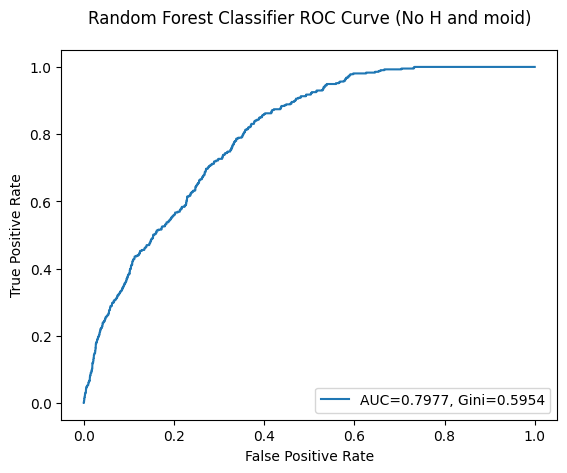

In [154]:
# Calculate the probability of each class for each data instance

y_rf_preds_prob_v5 = rf_model_v5.predict_proba(X_test_no_H_moid)[::,1]

# Display the ROC curve

fpr_rf_v5, tpr_rf_v5, _ = roc_curve(y_test, y_rf_preds_prob_v5)
auc_rf_v5 = round(roc_auc_score(y_test, y_rf_preds_prob_v5), 4)
gini_rf_v5 = round(((auc_rf_v5 * 2) - 1), 4)
label_string = f'AUC={auc_rf_v5}, Gini={gini_rf_v5}'
plt.plot(fpr_rf_v5, tpr_rf_v5, label=label_string)
plt.legend(loc=4)
plt.title('Random Forest Classifier ROC Curve (No H and moid)', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

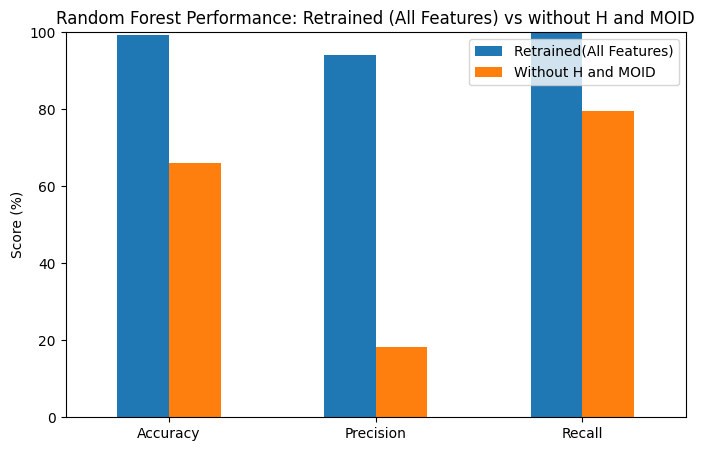

In [155]:
# Compare Random Forest performance using all features vs without H and MOID

metrics_df_v2 = pd.DataFrame({
    "Retrained(All Features)": [
        accuracy_score(y_test, y_rf_preds_v2),
        precision_score(y_test, y_rf_preds_v2),
        recall_score(y_test, y_rf_preds_v2)
    ],
    "Without H and MOID": [
        accuracy_score(y_test, y_rf_preds_v5),
        precision_score(y_test, y_rf_preds_v5),
        recall_score(y_test, y_rf_preds_v5)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df_v2.plot(kind="bar", figsize=(8,5))

plt.title("Random Forest Performance: Retrained (All Features) vs without H and MOID")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

### Train and evaluate Suport Vector Classifier model (without H and moid)

In [156]:
svm_model_v5 = SVC(random_state=RANDOM_STATE,
                   class_weight='balanced') # to deal with class imbalance

In [157]:
# Show how long the training takes

%%time

# Train the model without H and moid

svm_model_v5.fit(X_train_no_H_moid, y_train)

CPU times: user 8.36 s, sys: 14.6 ms, total: 8.38 s
Wall time: 9.24 s


SVC(class_weight='balanced', random_state=1776)

In [158]:
# Generate predictions against the scaled test set without H and moid

y_svm_preds_v5 = svm_model_v5.predict(X_test_no_H_moid)

In [159]:
# Evaluate the Confusion Matrix

print('Support Vector Classification Confusion Matrix (No H and moid)\n')

svm_cm_v5 = confusion_matrix(y_test, y_svm_preds_v5)

svm_cm_display_v5 = pd.DataFrame(svm_cm_v5,
                             index=['Actual Safe', 'Actual PHAs'],
                             columns=['Predicted Safe', 'Predicted PHAs'])

svm_cm_display_v5

Support Vector Classification Confusion Matrix (No H and moid)



,Predicted Safe,Predicted PHAs
Actual Safe,2551,1613
Actual PHAs,77,336


In [160]:
# Evaluate the Classification Report (No H and moid)

print('Support Vector Classification Report (No H and moid)\n')
print(classification_report(y_test,
                            y_svm_preds_v5,
                            target_names=['Safe', 'PHAs']))

Support Vector Classification Report (No H and moid)

              precision    recall  f1-score   support

        Safe       0.97      0.61      0.75      4164
        PHAs       0.17      0.81      0.28       413

    accuracy                           0.63      4577
   macro avg       0.57      0.71      0.52      4577
weighted avg       0.90      0.63      0.71      4577



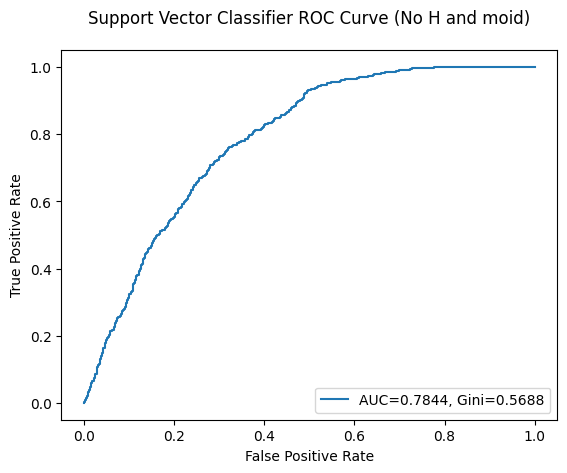

In [161]:
# Calculate the probability of each class for each data instance

y_svm_preds_prob_v5 = svm_model_v5.decision_function(X_test_no_H_moid)

# Display the ROC curve

fpr_svm_v5, tpr_svm_v5, _ = roc_curve(y_test, y_svm_preds_prob_v5)
auc_svm_v5 = round(roc_auc_score(y_test, y_svm_preds_prob_v5), 4)
gini_svm_v5 = round(((auc_svm_v5 * 2) - 1), 4)
label_string = f'AUC={auc_svm_v5}, Gini={gini_svm_v5}'
plt.plot(fpr_svm_v5, tpr_svm_v5, label=label_string)
plt.legend(loc=4)
plt.title('Support Vector Classifier ROC Curve (No H and moid)', y=1.05)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

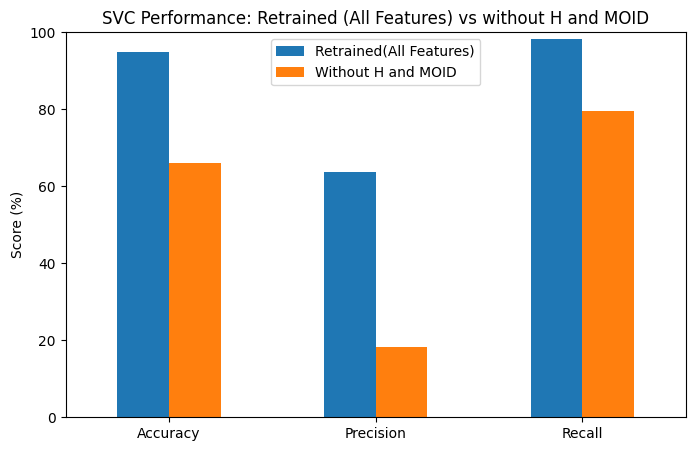

In [162]:
# Compare SVC performance with all features vs without H and MOID

metrics_df_v2 = pd.DataFrame({
    "Retrained(All Features)": [
        accuracy_score(y_test, y_svm_preds_v2),
        precision_score(y_test, y_svm_preds_v2),
        recall_score(y_test, y_svm_preds_v2)
    ],
    "Without H and MOID": [
        accuracy_score(y_test, y_rf_preds_v5),
        precision_score(y_test, y_rf_preds_v5),
        recall_score(y_test, y_rf_preds_v5)
    ]
}, index=["Accuracy", "Precision", "Recall"]) * 100

metrics_df_v2.plot(kind="bar", figsize=(8,5))

plt.title("SVC Performance: Retrained (All Features) vs without H and MOID")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.show()

## Appendix: Confusion Matrices used for Analysis and Reporting

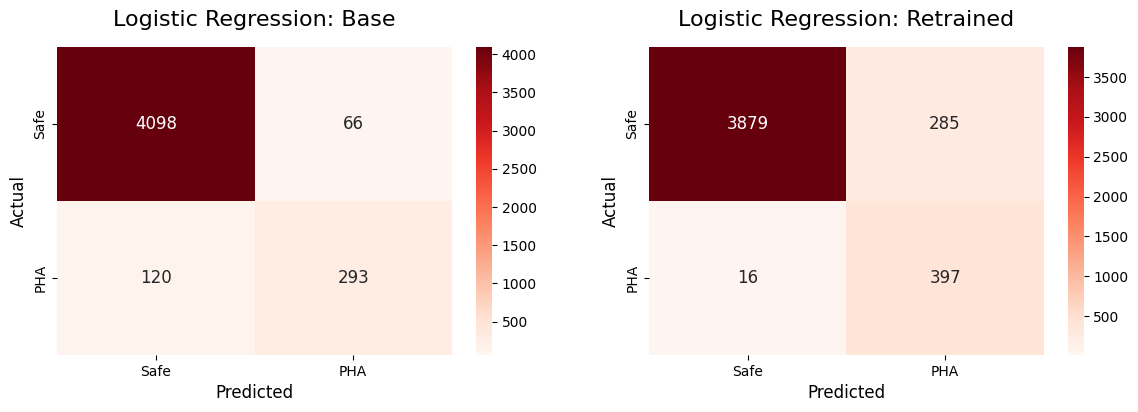

In [163]:
#Logistic

plt.figure(figsize=(14, 4))

#Base
plt.subplot(1, 2, 1)
sns.heatmap(lr_cm, annot=True, cmap='Reds', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Logistic Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Retrained
plt.subplot(1, 2, 2)
sns.heatmap(lr_cm_v2, annot=True, cmap='Reds', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Logistic Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.show()

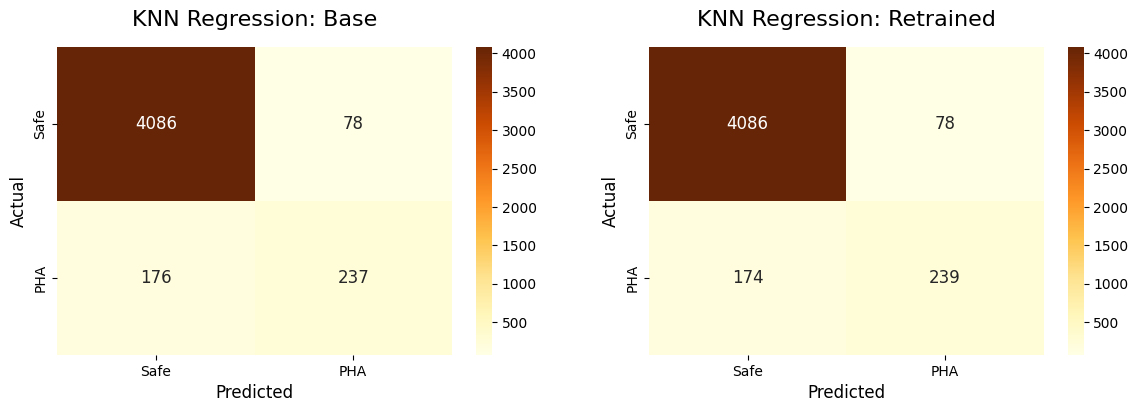

In [164]:
#KNN

plt.figure(figsize=(14, 4))

#Base
plt.subplot(1, 2, 1)
sns.heatmap(knn_cm, annot=True, cmap='YlOrBr', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('KNN Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Retrained
plt.subplot(1, 2, 2)
sns.heatmap(knn_cm_v2, annot=True, cmap='YlOrBr', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('KNN Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.show()

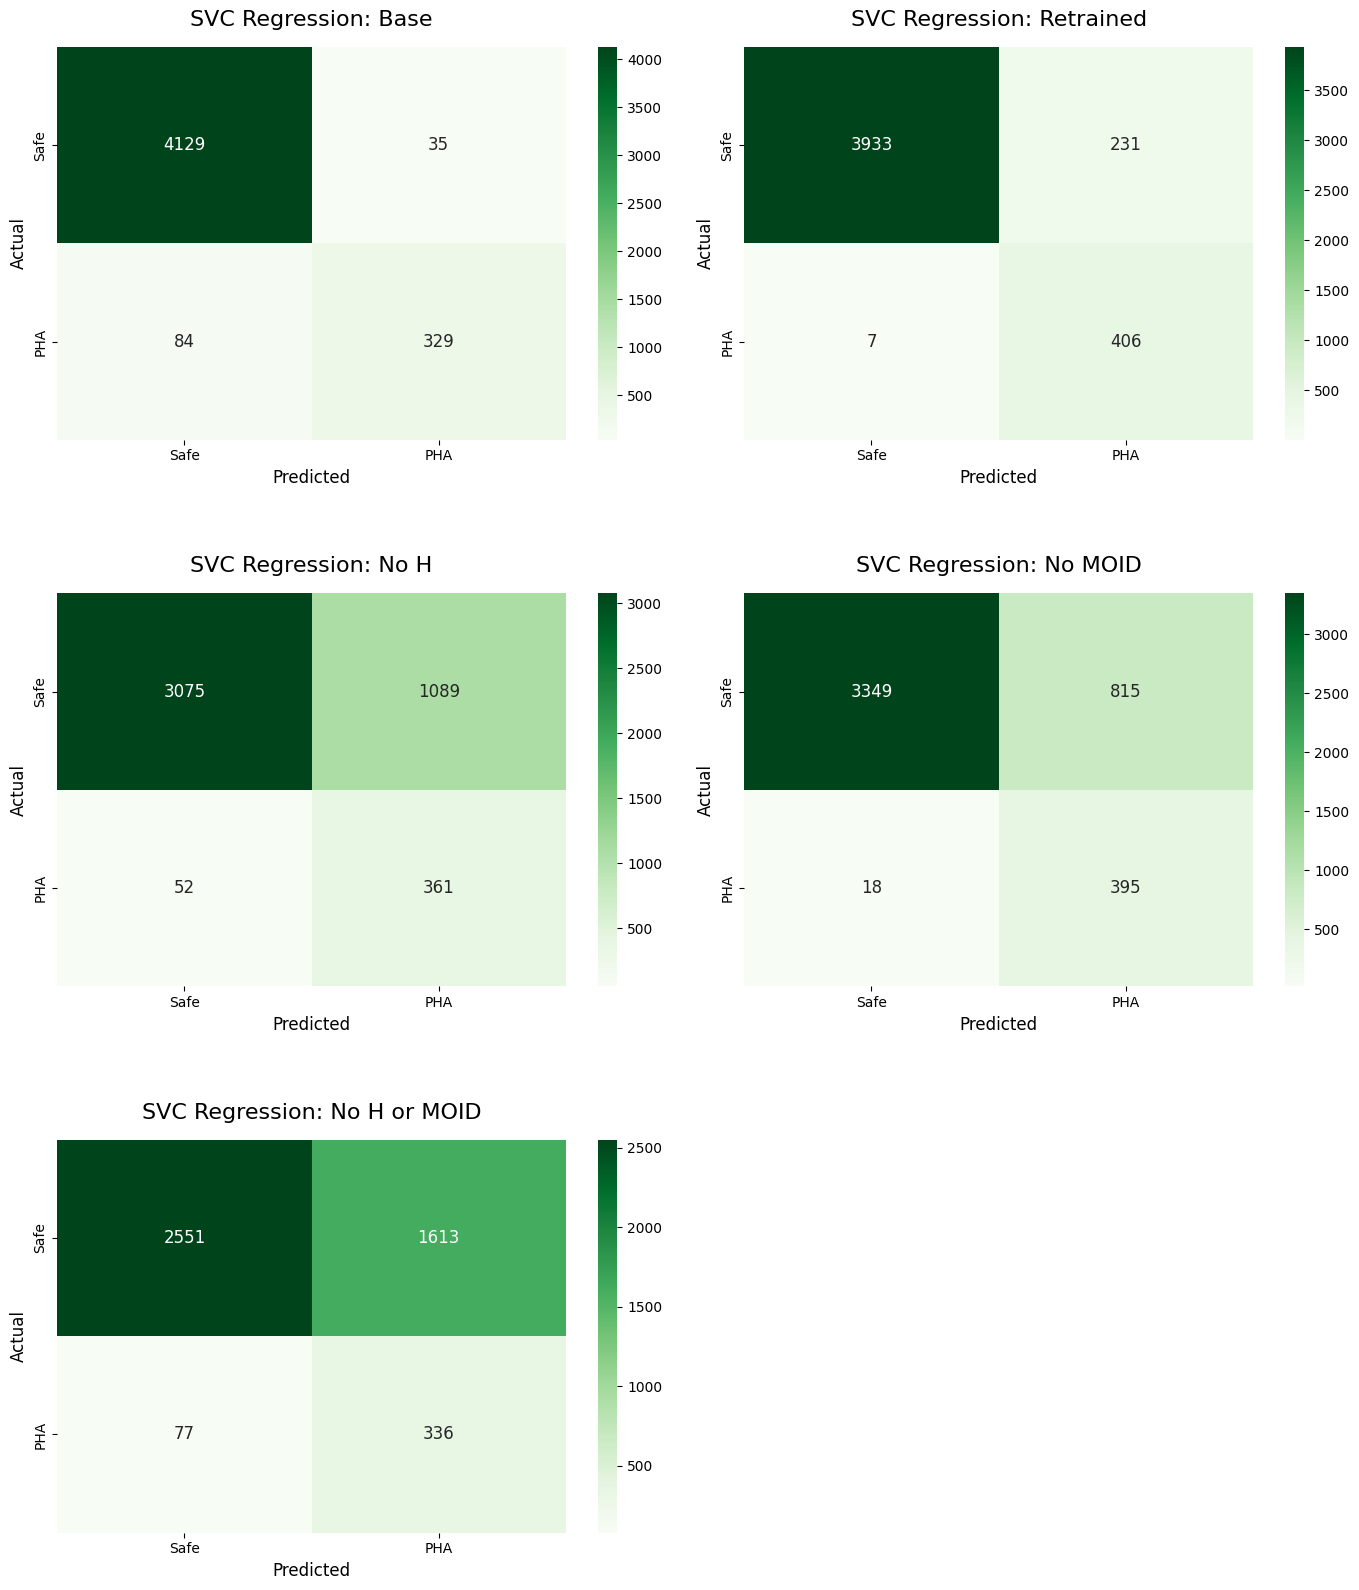

In [165]:
#SVM

plt.figure(figsize=(14, 16))

#Base
plt.subplot(3, 2, 1)
sns.heatmap(svm_cm, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Retrained
plt.subplot(3, 2, 2)
sns.heatmap(svm_cm_v2, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#No H
plt.subplot(3, 2, 3)
sns.heatmap(svm_cm_v3, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: No H', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#No MOID
plt.subplot(3, 2, 4)
sns.heatmap(svm_cm_v4, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: No MOID', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#No H & MOID
plt.subplot(3, 2, 5)
sns.heatmap(svm_cm_v5, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: No H or MOID', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout(h_pad=5.0)
plt.show()

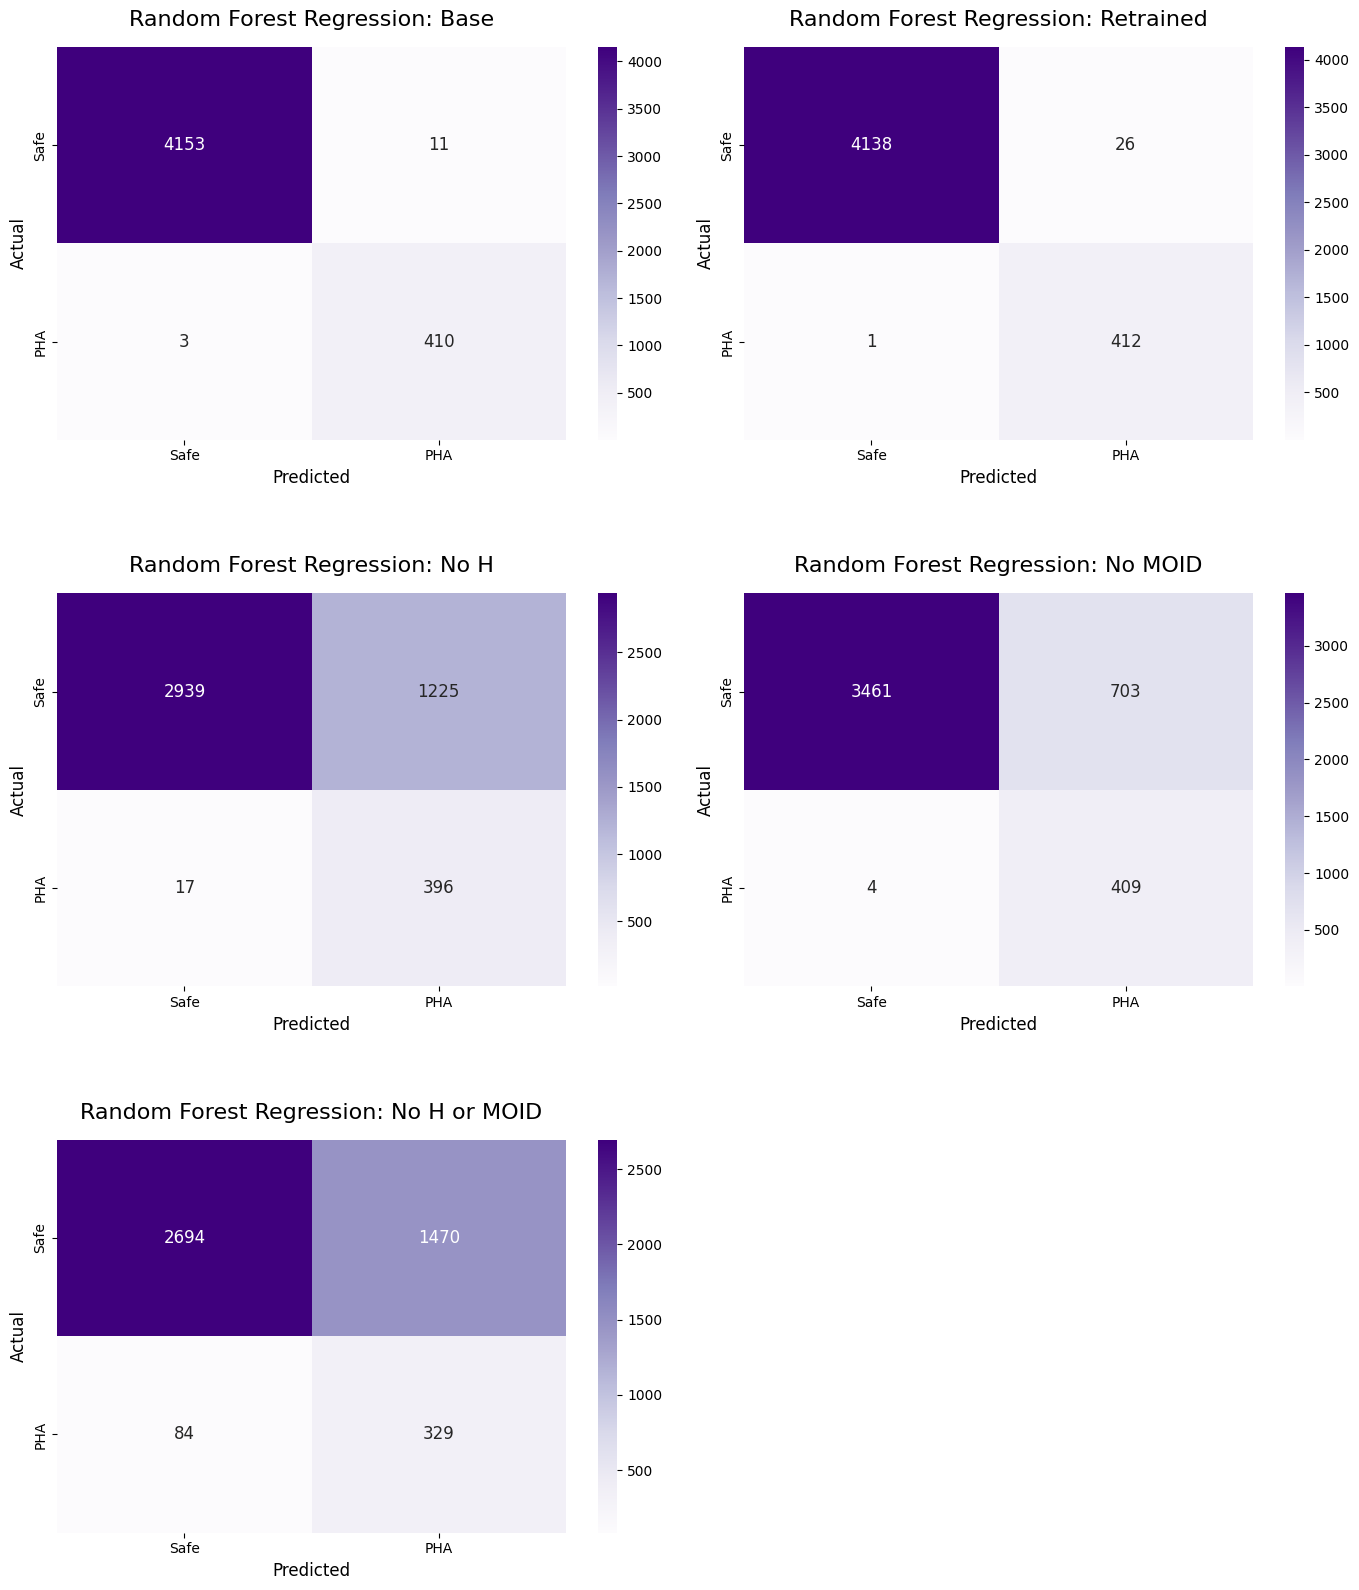

In [166]:
#Random Forest

plt.figure(figsize=(14, 16))

#Base
plt.subplot(3, 2, 1)
sns.heatmap(rf_cm, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Retrained
plt.subplot(3, 2, 2)
sns.heatmap(rf_cm_v2, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#No H
plt.subplot(3, 2, 3)
sns.heatmap(rf_cm_v3, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: No H', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#No MOID
plt.subplot(3, 2, 4)
sns.heatmap(rf_cm_v4, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: No MOID', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#No H or MOID
plt.subplot(3, 2, 5)
sns.heatmap(rf_cm_v5, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: No H or MOID', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout(h_pad=5.0)
plt.show()

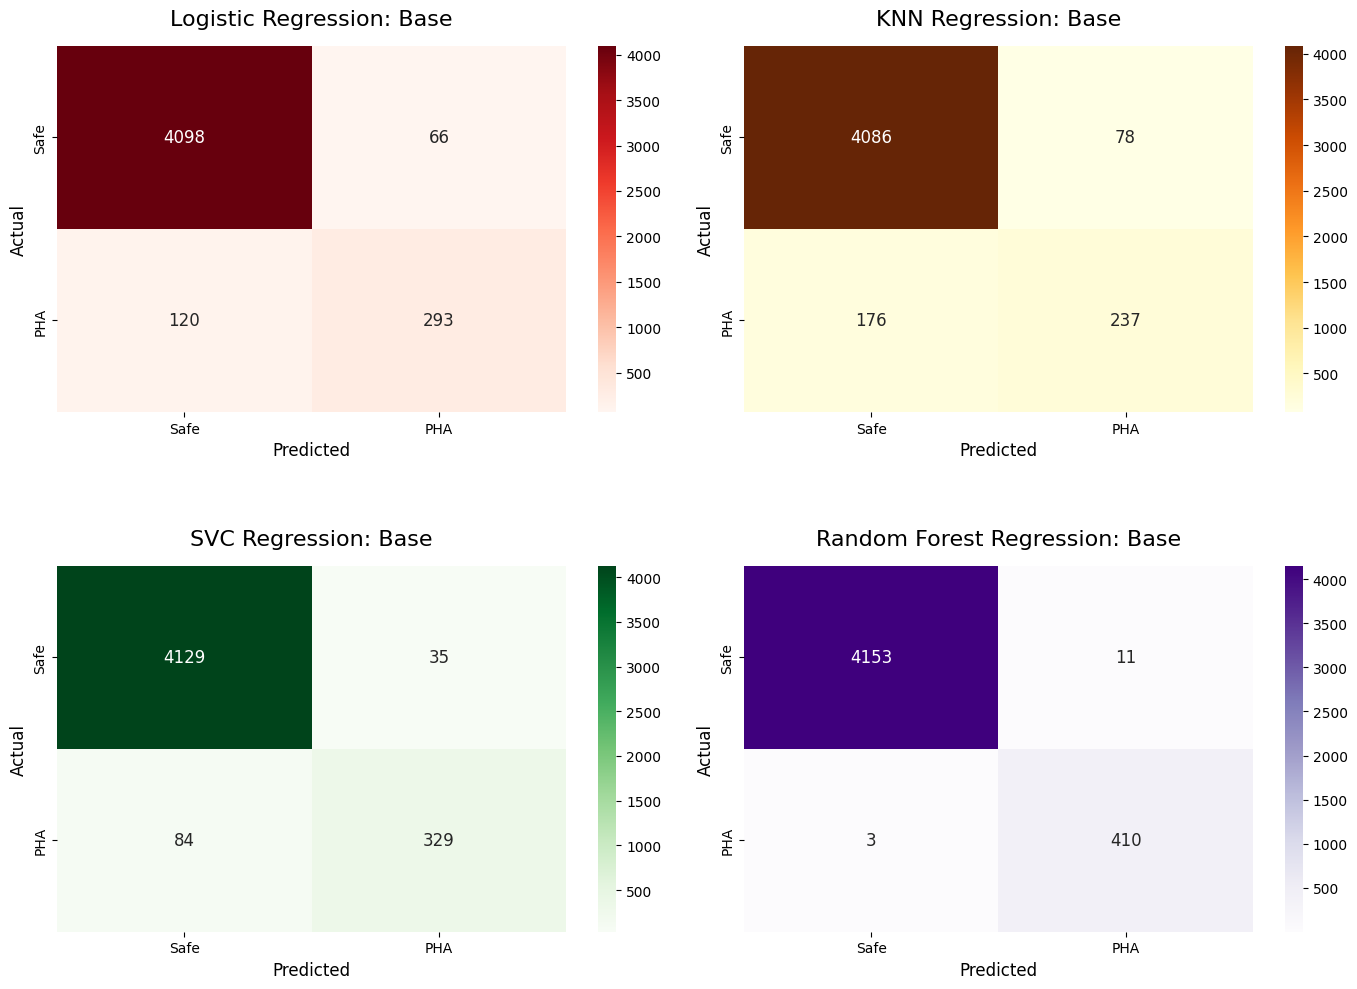

In [167]:
# Base Combined

plt.figure(figsize=(14, 10))

#Base LR
plt.subplot(2, 2, 1)
sns.heatmap(lr_cm, annot=True, cmap='Reds', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Logistic Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Base KNN
plt.subplot(2, 2, 2)
sns.heatmap(knn_cm, annot=True, cmap='YlOrBr', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('KNN Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Base SVM
plt.subplot(2, 2, 3)
sns.heatmap(svm_cm, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Base RF
plt.subplot(2, 2, 4)
sns.heatmap(rf_cm, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: Base', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout(h_pad=5.0)
plt.show()


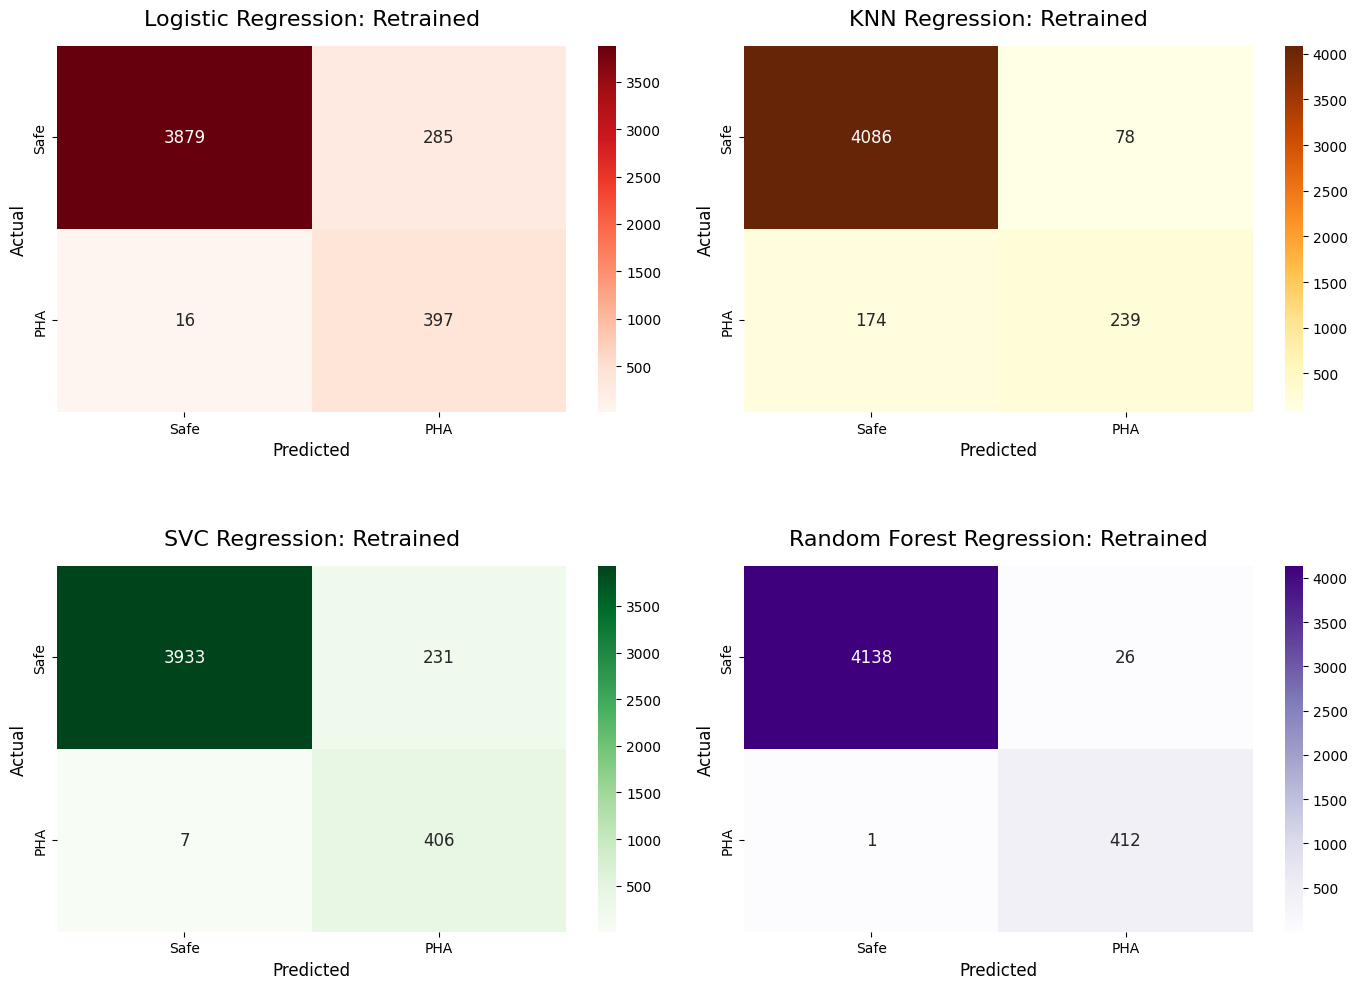

In [168]:
# Retrained Combined

plt.figure(figsize=(14, 10))

#Base LR
plt.subplot(2, 2, 1)
sns.heatmap(lr_cm_v2, annot=True, cmap='Reds', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Logistic Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Base KNN
plt.subplot(2, 2, 2)
sns.heatmap(knn_cm_v2, annot=True, cmap='YlOrBr', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('KNN Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Base SVM
plt.subplot(2, 2, 3)
sns.heatmap(svm_cm_v2, annot=True, cmap='Greens', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('SVC Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

#Base RF
plt.subplot(2, 2, 4)
sns.heatmap(rf_cm_v2, annot=True, cmap='Purples', fmt='d', annot_kws={"size": 12}, xticklabels=["Safe", "PHA"], yticklabels=["Safe", "PHA"])
plt.title('Random Forest Regression: Retrained', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout(h_pad=5.0)
plt.show()